In [21]:
import nbformat
from nbconvert import HTMLExporter

# Leer el notebook
with open('C:\\Users\\Usuario\\Documents\\Github\\Talvi\\notebooks\\vulnerabilidad-externa-vecm v4.ipynb', 'r') as f:
    notebook = nbformat.read(f, as_version=4)

# Convertir a HTML
html_exporter = HTMLExporter()
(body, resources) = html_exporter.from_notebook_node(notebook)

# Guardar el HTML
with open('output.html', 'w') as f:
    f.write(body)

In [2]:
# ==============================================================================
# FASE 1: CONFIGURACIÓN, CARGA Y PREPARACIÓN DE DATOS
# ==============================================================================

# --- 1. IMPORTACIÓN DE LIBRERÍAS ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
figures_dir = "figures"
os.makedirs(figures_dir, exist_ok=True)

# --- 2. CONFIGURACIÓN DEL ENTORNO ---
warnings.filterwarnings('ignore')
plt.style.use('default')
try:
    sns.set_palette("husl")
except:
    pass

# --- 3. CARGA Y PROCESAMIENTO INICIAL ---

# DataFrame de Indicadores Macro (será mensual)
df_indicadores = pd.read_csv('../data/indicadores/indicadores_macroeconomicos.csv',
                             sep=';', encoding='latin1')
df_indicadores = df_indicadores.set_index('fecha')
df_indicadores.index = df_indicadores.index.astype(str)
df_indicadores.index.name = 'fecha'

# DataFrame Termotrade (mensual)
df_termotrade = pd.read_csv('../data/indicadores/monthly_results_brazil.csv',
                            sep=";", encoding='latin1')
df_termotrade = df_termotrade[['date', 'ctot_level']]
df_termotrade = df_termotrade.rename(columns={'ctot_level': 'termoftrade'})
df_termotrade = df_termotrade.set_index('date')
df_termotrade.index = pd.to_datetime(df_termotrade.index).strftime('%Y%m')
df_termotrade.index.name = 'fecha'

# DataFrame PIB de Brasil (trimestral)
gdp_brazil = pd.read_csv('../data/QGDP/brazil.csv', sep=",", encoding='latin1')
gdp_brazil = gdp_brazil.set_index(gdp_brazil.columns[0])
gdp_brazil.index = pd.to_datetime(gdp_brazil.index).strftime('%Y%m')
gdp_brazil = gdp_brazil.rename(columns={gdp_brazil.columns[0]: 'GDP_BRAZIL'})

# --- 4. CONSOLIDACIÓN DE DATOS MENSUALES ---
# Unimos los dos dataframes mensuales
df_monthly = df_indicadores.join(df_termotrade, how='outer')

# Creación de la variable dummy para la pandemia sobre los datos mensuales
df_monthly['pandemia_dummy'] = 0
start_date_dummy = '202003'
end_date_dummy = '202009'
df_monthly.loc[start_date_dummy:end_date_dummy, 'pandemia_dummy'] = 1

# --- 5. ALINEACIÓN DE FRECUENCIAS (MENSUAL A TRIMESTRAL) ---
print("="*50)
print("🔧 ALINEANDO DATOS A FRECUENCIA TRIMESTRAL")
print("="*50)

# Convertir índices a Datetime para poder remuestrear
gdp_brazil.index = pd.to_datetime(gdp_brazil.index, format='%Y%m')
df_monthly.index = pd.to_datetime(df_monthly.index, format='%Y%m')
print("✅ Índices convertidos a formato Datetime.")

# Remuestrear los datos mensuales a trimestrales
# Usamos .mean() para los indicadores continuos y .max() para la dummy
df_monthly_quarterly = df_monthly.drop(columns=['pandemia_dummy']).resample('Q').mean()
df_dummy_quarterly = df_monthly[['pandemia_dummy']].resample('Q').max()

# Unir los datos mensuales ya agregados
df_monthly_agg = df_monthly_quarterly.join(df_dummy_quarterly)
print("✅ Datos mensuales agregados a trimestres.")

# Estandarizar los índices de ambos DataFrames al inicio del trimestre
# Esto asegura una unión perfecta
gdp_brazil.index = gdp_brazil.index.to_period('Q').start_time
df_monthly_agg.index = df_monthly_agg.index.to_period('Q').start_time
print("✅ Índices estandarizados al inicio del trimestre.")

# --- 6. CREACIÓN DEL DATAFRAME FINAL ---
# Unir los datos trimestrales del PIB con los datos mensuales agregados
df_aligned = gdp_brazil.join(df_monthly_agg, how='inner')
df_aligned.dropna(inplace=True)

# Crear la versión en logaritmo del PIB
df_aligned['log_gdp_brazil'] = np.log(df_aligned['GDP_BRAZIL'])

# 2. Aplicar logaritmo a términos de intercambio (V3 no lo hacía)
df_aligned['log_tot_brazil'] = np.log(df_aligned['termoftrade'])

# 3. Crear IP_G7 ponderado (faltaba en V3)
df_aligned['log_ip_g7'] = np.log(df_aligned['PI_USA'] * 0.40 + 
                                 df_aligned['PI_FRA'] * 0.15 + 
                                 df_aligned['PI_GER'] * 0.20 + 
                                 df_aligned['PI_ITA'] * 0.12 + 
                                 df_aligned['PI_UK'] * 0.13)

# 4. Crear variables financieras (faltaban en V3)
df_aligned['us_10y'] = df_aligned['DGS10']
df_aligned['risk_spread'] = df_aligned['SPREAD_USA']

# Reordenar columnas para tener las variables principales al final
main_vars = ['GDP_BRAZIL', 'log_gdp_brazil']
other_vars = [col for col in df_aligned.columns if col not in main_vars]
df_aligned = df_aligned[main_vars + other_vars]


print(f"\n📊 DATOS FINALES ALINEADOS:")
print(f"   Observaciones: {len(df_aligned)}")
if not df_aligned.empty:
    print(f"   Período: {df_aligned.index.min().strftime('%Y-%m-%d')} a {df_aligned.index.max().strftime('%Y-%m-%d')}")
    print(f"   Columnas: {list(df_aligned.columns)}")
else:
    print("⚠️ ADVERTENCIA: El DataFrame está vacío. Revisa los rangos de fechas.")

print("\n primeiras 5 observações do dataset final:")
display(df_aligned.head())

c:\Users\Usuario\anaconda3\envs\tftimeseriesII\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
c:\Users\Usuario\anaconda3\envs\tftimeseriesII\lib\site-packages\numpy\.libs\libopenblas.EL2C6PLE4ZYW3ECEVIV3OXXGRN2NRFM2.gfortran-win_amd64.dll
c:\Users\Usuario\anaconda3\envs\tftimeseriesII\lib\site-packages\numpy\.libs\libopenblas.XWYDX2IKJW2NMTWSFYNGFUWKQU3LYTCZ.gfortran-win_amd64.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


🔧 ALINEANDO DATOS A FRECUENCIA TRIMESTRAL
✅ Índices convertidos a formato Datetime.
✅ Datos mensuales agregados a trimestres.
✅ Índices estandarizados al inicio del trimestre.

📊 DATOS FINALES ALINEADOS:
   Observaciones: 100
   Período: 2000-01-01 a 2024-10-01
   Columnas: ['GDP_BRAZIL', 'log_gdp_brazil', 'PI_USA', 'PI_FRA', 'PI_GER', 'PI_ITA', 'PI_UK', 'DGS10', 'SPREAD_USA', 'termoftrade', 'pandemia_dummy', 'log_tot_brazil', 'log_ip_g7', 'us_10y', 'risk_spread']

 primeiras 5 observações do dataset final:


,GDP_BRAZIL,log_gdp_brazil,PI_USA,PI_FRA,PI_GER,PI_ITA,PI_UK,DGS10,SPREAD_USA,termoftrade,pandemia_dummy,log_tot_brazil,log_ip_g7,us_10y,risk_spread
2000-01-01,192382.2,12.167239,91.738900,109.200000,83.066667,119.500000,76.533333,6.479007,5.018454,99.923617,0,4.604406,4.543063,6.479007,5.018454
2000-04-01,194948.4,12.180490,92.867467,110.933333,85.300000,121.700000,77.433333,6.176085,5.960372,99.878941,0,4.603959,4.559308,6.176085,5.960372
2000-07-01,197616.2,12.194082,92.803667,111.100000,86.766667,121.633333,78.133333,5.893029,6.312758,99.783583,0,4.603004,4.563234,5.893029,6.312758
2000-10-01,199860.6,12.205375,92.548700,112.500000,87.100000,123.966667,79.700000,5.565405,8.132197,99.716377,0,4.602330,4.570076,5.565405,8.132197
2001-01-01,200333.4,12.207738,91.411467,113.166667,87.500000,121.766667,80.400000,5.048451,8.006848,99.756359,0,4.602731,4.565427,5.048451,8.006848


In [3]:
# ==============================================================================
# FASE 2: DIAGNÓSTICO DE PROPIEDADES TEMPORALES
# ==============================================================================

# --- 1. IMPORTACIÓN DE LIBRERÍAS PARA DIAGNÓSTICO ---
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.vector_ar.vecm import coint_johansen
import pandas as pd

# --- 2. FUNCIONES DE AYUDA PARA LOS TESTS ---

def test_unit_root_summary(series, name):
    """
    Ejecuta una batería de tests de raíz unitaria (ADF y KPSS) y devuelve
    un resumen y una conclusión sobre el orden de integración.
    """
    results = {'Variable': name}
    
    # Test ADF (H0: Hay raíz unitaria / No estacionaria)
    adf_test = adfuller(series.dropna(), regression='c', autolag='AIC')
    results['ADF_p_value'] = adf_test[1]
    
    # Test KPSS (H0: Es estacionaria)
    # Nota: Invertimos la lógica del p-valor para el resultado
    try:
        kpss_test = kpss(series.dropna(), regression='c', nlags='auto')
        results['KPSS_p_value'] = kpss_test[1]
    except Exception as e:
        results['KPSS_p_value'] = None # Puede fallar si la serie es muy persistente
        
    # Conclusión basada en la combinación de tests
    # Consideramos I(1) si ADF no rechaza H0 Y KPSS rechaza H0
    is_i1 = False
    if results['ADF_p_value'] > 0.05:
        if results['KPSS_p_value'] is not None and results['KPSS_p_value'] < 0.05:
            is_i1 = True
        elif results['KPSS_p_value'] is None: # Si KPSS falla, confiamos en ADF
            is_i1 = True
            
    results['Conclusion'] = 'I(1)' if is_i1 else 'I(0)'
    
    return results

# --- 3. EJECUCIÓN DE TESTS DE RAÍZ UNITARIA ---
print("="*60)
print("📊 1. ANÁLISIS DE RAÍZ UNITARIA (ESTACIONARIEDAD)")
print("="*60)

# ✅ Variables según metodología V2 (5 variables principales)
variables_to_test = ['log_gdp_brazil', 'log_ip_g7', 'log_tot_brazil', 'us_10y', 'risk_spread']


all_stationarity_results = []
for var in variables_to_test:
    if var in df_aligned.columns:
        result = test_unit_root_summary(df_aligned[var], var)
        all_stationarity_results.append(result)

# Mostrar resultados en una tabla
summary_table = pd.DataFrame(all_stationarity_results).set_index('Variable')
print(summary_table)

# Identificar variables I(1) para el siguiente paso
i1_variables = summary_table[summary_table['Conclusion'] == 'I(1)'].index.tolist()
print(f"\n✅ Variables identificadas como I(1) para cointegración: {i1_variables}")


# --- 4. TEST DE COINTEGRACIÓN DE JOHANSEN ---
print("\n" + "="*60)
print("🔗 2. TEST DE COINTEGRACIÓN DE JOHANSEN (SOBRE VARIABLES I(1))")
print("="*60)

if len(i1_variables) >= 2:
    data_johansen = df_aligned[i1_variables].dropna()
    
    # det_order=1 asume una tendencia lineal en los datos, que es común
    # k_ar_diff=2 significa que el modelo subyacente tiene 3 lags (p=k+1)
    johansen_result = coint_johansen(data_johansen.values, det_order=1, k_ar_diff=2)
    
    print(f"Variables incluidas en el test: {i1_variables}")
    
    # Interpretar el test de la traza
    print("\nResultados del Test de la Traza:")
    print("--------------------------------------------------")
    print(" H0: r=i | Estadístico | Valor Crítico 5% | Conclusión")
    print("--------------------------------------------------")
    
    num_relations = 0
    for i in range(len(i1_variables)):
        trace_stat = johansen_result.lr1[i]
        crit_val = johansen_result.cvt[i, 1]
        conclusion = "Rechaza H0" if trace_stat > crit_val else "No Rechaza H0"
        print(f" r<={i}   | {trace_stat:>11.3f} | {crit_val:>16.3f} | {conclusion}")
        if trace_stat > crit_val:
            num_relations = i + 1
            
    print("--------------------------------------------------")
    print(f"\n✅ Veredicto: Se encontraron {num_relations} relación(es) de cointegración.")
    
else:
    print("⚠️ No se encontraron suficientes variables I(1) para realizar el test de cointegración.")

📊 1. ANÁLISIS DE RAÍZ UNITARIA (ESTACIONARIEDAD)
                ADF_p_value  KPSS_p_value Conclusion
Variable                                            
log_gdp_brazil     0.463526      0.010000       I(1)
log_ip_g7          0.009664      0.094195       I(0)
log_tot_brazil     0.145009      0.034206       I(1)
us_10y             0.152874      0.010000       I(1)
risk_spread        0.004912      0.077011       I(0)

✅ Variables identificadas como I(1) para cointegración: ['log_gdp_brazil', 'log_tot_brazil', 'us_10y']

🔗 2. TEST DE COINTEGRACIÓN DE JOHANSEN (SOBRE VARIABLES I(1))
Variables incluidas en el test: ['log_gdp_brazil', 'log_tot_brazil', 'us_10y']

Resultados del Test de la Traza:
--------------------------------------------------
 H0: r=i | Estadístico | Valor Crítico 5% | Conclusión
--------------------------------------------------
 r<=0   |      38.450 |           35.012 | Rechaza H0
 r<=1   |      12.084 |           18.398 | No Rechaza H0
 r<=2   |       1.146 |         

C:\Users\Usuario\AppData\Local\Temp\ipykernel_63544\3170422310.py:26: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = kpss(series.dropna(), regression='c', nlags='auto')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_63544\3170422310.py:26: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = kpss(series.dropna(), regression='c', nlags='auto')


In [4]:
# ==============================================================================
# FASE 3: ESTIMACIÓN DEL MODELO VECM ÓPTIMO (CON TRATAMIENTO COVID)
# ==============================================================================

from statsmodels.regression.linear_model import OLS
import statsmodels.api as sm
import numpy as np
import pandas as pd

print("="*80)
print("🎯 FASE 3: ESTIMACIÓN DEL MODELO VECM ÓPTIMO")
print("🦠 ESTRATEGIA: Control de Efectos COVID-19")
print("="*80)

# ==============================================================================
# 3.0: PREPARACIÓN - Crear Dummies COVID
# ==============================================================================

print("\n📊 PASO 0: Preparación de Variables de Control COVID")
print("-"*60)

# Crear dummies para dos fases del COVID
df_aligned['covid_crash'] = 0
df_aligned['covid_recovery'] = 0

# Fase 1: Caída abrupta (2020Q1-Q2)
crash_start = '2020-01'
crash_end = '2020-06'
df_aligned.loc[crash_start:crash_end, 'covid_crash'] = 1

# Fase 2: Recuperación distorsionada (2020Q3-2021Q2)
recovery_start = '2020-07'
recovery_end = '2021-06'
df_aligned.loc[recovery_start:recovery_end, 'covid_recovery'] = 1

n_crash = df_aligned['covid_crash'].sum()
n_recovery = df_aligned['covid_recovery'].sum()
n_total_covid = n_crash + n_recovery

print(f"✅ Dummies COVID creadas:")
print(f"   • covid_crash (2020Q1-Q2): {n_crash} observaciones")
print(f"   • covid_recovery (2020Q3-2021Q2): {n_recovery} observaciones")
print(f"   • Total período COVID: {n_total_covid} observaciones ({n_total_covid/len(df_aligned)*100:.1f}%)")

# ==============================================================================
# 3.1: RELACIÓN DE LARGO PLAZO (Sin cambios)
# ==============================================================================

print("\n📊 PASO 1: Relación de Equilibrio de Largo Plazo")
print("-"*60)

dependent_var = 'log_gdp_brazil'
coint_vars_i1 = ['log_tot_brazil', 'us_10y']

y_coint = df_aligned[dependent_var]
X_coint = df_aligned[coint_vars_i1]
X_coint_const = sm.add_constant(X_coint)

modelo_coint = OLS(y_coint, X_coint_const).fit()
ect = modelo_coint.resid
ect.name = 'ECT'

print(f"✅ Relación de cointegración estimada (toda la muestra):")
print(f"   log_gdp = {modelo_coint.params['const']:.4f} + "
      f"{modelo_coint.params['log_tot_brazil']:.4f}*log_tot + "
      f"{modelo_coint.params['us_10y']:.4f}*us_10y")

# ==============================================================================
# 3.2: MODELO 1 - Con Controles COVID (Dummy Saturación)
# ==============================================================================

print("\n" + "="*60)
print("🔍 MODELO 1: Búsqueda Óptima CON Controles COVID")
print("="*60)

def find_optimal_with_covid_controls(df_aligned, ect, max_ect_lags=3, max_var_lags=3):
    """
    Búsqueda óptima INCLUYENDO dummies COVID como controles
    """
    
    variables_i0 = ['log_ip_g7', 'risk_spread']
    coint_vars_i1 = ['log_tot_brazil', 'us_10y']
    covid_controls = ['covid_crash', 'covid_recovery']
    
    df_diff = df_aligned.diff().dropna()
    y_ecm = df_diff['log_gdp_brazil']
    
    results = []
    
    for ect_lags in range(1, max_ect_lags + 1):
        for var_lags in range(0, max_var_lags + 1):
            
            try:
                X_list = []
                
                # ECT lags
                for lag in range(1, ect_lags + 1):
                    X_list.append(ect.shift(lag).rename(f'ECT_L{lag}'))
                
                # Variables I(1) diferenciadas
                for var in coint_vars_i1:
                    X_list.append(df_diff[var].rename(f'D_{var}_L0'))
                    for lag in range(1, var_lags + 1):
                        X_list.append(df_diff[var].shift(lag).rename(f'D_{var}_L{lag}'))
                
                # Variables I(0) en niveles
                for var in variables_i0:
                    X_list.append(df_aligned[var].rename(f'{var}_L0'))
                    for lag in range(1, var_lags + 1):
                        X_list.append(df_aligned[var].shift(lag).rename(f'{var}_L{lag}'))
                
                # ✅ AÑADIR: Controles COVID
                for covid_var in covid_controls:
                    X_list.append(df_aligned[covid_var])
                
                X = pd.concat(X_list, axis=1).dropna()
                y_aligned = y_ecm.loc[X.index]
                X_with_const = sm.add_constant(X)
                
                model = OLS(y_aligned, X_with_const).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
                
                ect_coef_l1 = model.params.get('ECT_L1', 0)
                ect_pval_l1 = model.pvalues.get('ECT_L1', 1)
                is_stable = (ect_coef_l1 < 0) and (ect_pval_l1 < 0.10)
                
                results.append({
                    'ect_lags': ect_lags,
                    'var_lags': var_lags,
                    'aic': model.aic,
                    'bic': model.bic,
                    'r2_adj': model.rsquared_adj,
                    'nobs': model.nobs,
                    'ect_l1_coef': ect_coef_l1,
                    'ect_l1_pval': ect_pval_l1,
                    'is_stable': is_stable,
                    'model': model
                })
                
            except:
                continue
    
    results_df = pd.DataFrame(results)
    stable_models = results_df[results_df['is_stable'] == True].copy()
    
    print(f"📊 Resultados (CON controles COVID):")
    print(f"   • Especificaciones evaluadas: {len(results_df)}")
    print(f"   • Especificaciones ESTABLES: {len(stable_models)}")
    
    if len(stable_models) > 0:
        optimal = stable_models.nsmallest(1, 'aic').iloc[0]
        print(f"\n🏆 MODELO ÓPTIMO:")
        print(f"   • ECT lags: {int(optimal['ect_lags'])}")
        print(f"   • Variable lags: {int(optimal['var_lags'])}")
        print(f"   • AIC: {optimal['aic']:.3f}")
        print(f"   • R² Ajustado: {optimal['r2_adj']:.4f}")
        print(f"   • ECT(t-1): {optimal['ect_l1_coef']:.4f} (p={optimal['ect_l1_pval']:.4f})")
        
        top3 = stable_models.nsmallest(3, 'aic')[['ect_lags', 'var_lags', 'aic', 'r2_adj', 'ect_l1_coef']]
        print(f"\n📋 Top 3 Modelos:")
        print(top3.to_string(index=False))
    else:
        optimal = results_df.nsmallest(1, 'aic').iloc[0]
        print(f"\n⚠️ No se encontraron modelos estables, usando mejor por AIC")
    
    return {'optimal': optimal, 'all_results': results_df, 'stable_models': stable_models}

# Ejecutar búsqueda
spec_with_covid = find_optimal_with_covid_controls(df_aligned, ect)

# ==============================================================================
# 3.3: MODELO 2 - Sin Período COVID (Análisis de Robustez)
# ==============================================================================

print("\n" + "="*60)
print("🔬 MODELO 2: Análisis de Robustez (Sin Período COVID)")
print("="*60)

# Crear máscara para excluir TODO el período COVID
covid_mask = (df_aligned.index >= '2020-01') & (df_aligned.index <= '2021-06')
n_excluidas = covid_mask.sum()

print(f"📊 Muestra de robustez:")
print(f"   • Observaciones originales: {len(df_aligned)}")
print(f"   • Observaciones excluidas (COVID): {n_excluidas}")
print(f"   • Observaciones para estimación: {(~covid_mask).sum()}")

# Estimar relación de cointegración SIN COVID
y_coint_clean = df_aligned.loc[~covid_mask, dependent_var]
X_coint_clean = df_aligned.loc[~covid_mask, coint_vars_i1]
X_coint_clean_const = sm.add_constant(X_coint_clean)

modelo_coint_clean = OLS(y_coint_clean, X_coint_clean_const).fit()

print(f"\n✅ Relación de cointegración (sin COVID):")
print(f"   log_gdp = {modelo_coint_clean.params['const']:.4f} + "
      f"{modelo_coint_clean.params['log_tot_brazil']:.4f}*log_tot + "
      f"{modelo_coint_clean.params['us_10y']:.4f}*us_10y")

# Calcular ECT para TODA la muestra usando coeficientes limpios
ect_clean = y_coint - modelo_coint_clean.predict(X_coint_const)
ect_clean.name = 'ECT_clean'

# Buscar especificación óptima SIN COVID (sin dummies, muestra reducida)
def find_optimal_without_covid(df_aligned, ect, covid_mask, max_ect_lags=3, max_var_lags=3):
    """
    Búsqueda en muestra SIN período COVID
    """
    
    variables_i0 = ['log_ip_g7', 'risk_spread']
    coint_vars_i1 = ['log_tot_brazil', 'us_10y']
    
    df_diff = df_aligned.diff().dropna()
    y_ecm = df_diff['log_gdp_brazil']
    
    # Aplicar máscara COVID
    clean_mask = ~covid_mask
    
    results = []
    
    for ect_lags in range(1, max_ect_lags + 1):
        for var_lags in range(0, max_var_lags + 1):
            
            try:
                X_list = []
                
                for lag in range(1, ect_lags + 1):
                    X_list.append(ect.shift(lag).rename(f'ECT_L{lag}'))
                
                for var in coint_vars_i1:
                    X_list.append(df_diff[var].rename(f'D_{var}_L0'))
                    for lag in range(1, var_lags + 1):
                        X_list.append(df_diff[var].shift(lag).rename(f'D_{var}_L{lag}'))
                
                for var in variables_i0:
                    X_list.append(df_aligned[var].rename(f'{var}_L0'))
                    for lag in range(1, var_lags + 1):
                        X_list.append(df_aligned[var].shift(lag).rename(f'{var}_L{lag}'))
                
                X = pd.concat(X_list, axis=1).dropna()
                
                # ✅ FILTRAR: Solo observaciones fuera de COVID
                X_clean = X.loc[clean_mask[X.index]]
                y_clean = y_ecm.loc[X_clean.index]
                
                X_with_const = sm.add_constant(X_clean)
                model = OLS(y_clean, X_with_const).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
                
                ect_coef_l1 = model.params.get('ECT_L1', 0)
                ect_pval_l1 = model.pvalues.get('ECT_L1', 1)
                is_stable = (ect_coef_l1 < 0) and (ect_pval_l1 < 0.10)
                
                results.append({
                    'ect_lags': ect_lags,
                    'var_lags': var_lags,
                    'aic': model.aic,
                    'bic': model.bic,
                    'r2_adj': model.rsquared_adj,
                    'nobs': model.nobs,
                    'ect_l1_coef': ect_coef_l1,
                    'ect_l1_pval': ect_pval_l1,
                    'is_stable': is_stable,
                    'model': model
                })
                
            except:
                continue
    
    results_df = pd.DataFrame(results)
    
    # ✅ VALIDACIÓN: Verificar que hay resultados
    if len(results_df) == 0:
        print(f"\n⚠️ No se pudieron estimar modelos en muestra sin COVID")
        print(f"   Retornando None - se usará modelo con controles")
        return None
    
    stable_models = results_df[results_df['is_stable'] == True].copy()
    
    print(f"\n📊 Resultados (SIN período COVID):")
    print(f"   • Especificaciones evaluadas: {len(results_df)}")
    print(f"   • Especificaciones ESTABLES: {len(stable_models)}")
    
    if len(stable_models) > 0:
        optimal = stable_models.nsmallest(1, 'aic').iloc[0]
        print(f"\n🏆 MODELO ÓPTIMO (muestra limpia):")
        print(f"   • ECT lags: {int(optimal['ect_lags'])}")
        print(f"   • Variable lags: {int(optimal['var_lags'])}")
        print(f"   • AIC: {optimal['aic']:.3f}")
        print(f"   • R² Ajustado: {optimal['r2_adj']:.4f}")
        print(f"   • ECT(t-1): {optimal['ect_l1_coef']:.4f} (p={optimal['ect_l1_pval']:.4f})")
    else:
        optimal = results_df.nsmallest(1, 'aic').iloc[0]
        print(f"\n⚠️ No modelos estables, usando mejor por AIC")
    
    return {'optimal': optimal, 'all_results': results_df, 'stable_models': stable_models}

# Ejecutar búsqueda sin COVID
# Ejecutar búsqueda sin COVID
spec_without_covid = find_optimal_without_covid(df_aligned, ect, covid_mask)

# ✅ VALIDACIÓN: Si falla sin COVID, usar solo modelo con controles
if spec_without_covid is None:
    print(f"\n⚠️ Modelo sin COVID no disponible - continuando solo con modelo con controles")
    modelo_sin_covid = None
else:
    modelo_sin_covid = spec_without_covid['optimal']['model']

# ==============================================================================
# 3.4: COMPARACIÓN DE MODELOS
# ==============================================================================

print("\n" + "="*80)
print("📊 PASO 4: Comparación de Estrategias")
print("="*80)

modelo_original_r2 = 0.172
modelo_original_aic = -542.847
modelo_original_ect = -0.0492
modelo_original_pval = 0.072

modelo_covid = spec_with_covid['optimal']['model']
# Ya definido arriba con validación

comparison_data = {
    'Métrica': [
        'R² Ajustado',
        'AIC',
        'Observaciones',
        'ECT coef',
        'ECT p-valor',
        'COVID crash coef',
        'COVID recovery coef'
    ],
    'Original\n(sin controles)': [
        f"{modelo_original_r2:.4f}",
        f"{modelo_original_aic:.3f}",
        "99",
        f"{modelo_original_ect:.4f}",
        f"{modelo_original_pval:.4f}",
        "N/A",
        "N/A"
    ],
    'Modelo 1\n(con COVID dummies)': [
        f"{modelo_covid.rsquared_adj:.4f}",
        f"{modelo_covid.aic:.3f}",
        f"{int(modelo_covid.nobs)}",
        f"{modelo_covid.params.get('ECT_L1', np.nan):.4f}",
        f"{modelo_covid.pvalues.get('ECT_L1', np.nan):.4f}",
        f"{modelo_covid.params.get('covid_crash', np.nan):.4f}",
        f"{modelo_covid.params.get('covid_recovery', np.nan):.4f}"
    ],
    'Modelo 2\n(sin período COVID)': [
        f"{modelo_sin_covid.rsquared_adj:.4f}" if modelo_sin_covid else "N/A",
        f"{modelo_sin_covid.aic:.3f}" if modelo_sin_covid else "N/A",
        f"{int(modelo_sin_covid.nobs)}" if modelo_sin_covid else "N/A",
        f"{modelo_sin_covid.params.get('ECT_L1', np.nan):.4f}" if modelo_sin_covid else "N/A",
        f"{modelo_sin_covid.pvalues.get('ECT_L1', np.nan):.4f}" if modelo_sin_covid else "N/A",
        "N/A",
        "N/A"
    ]
}

comparison = pd.DataFrame(comparison_data)
print("\n" + comparison.to_string(index=False))

# Calcular mejoras
mejora_r2_covid = (modelo_covid.rsquared_adj - modelo_original_r2) * 100

print(f"\n📈 MEJORAS VS. MODELO ORIGINAL:")
print(f"   • Con COVID dummies: R² +{mejora_r2_covid:.1f} puntos porcentuales")

if modelo_sin_covid is not None:
    mejora_r2_sin = (modelo_sin_covid.rsquared_adj - modelo_original_r2) * 100
    print(f"   • Sin período COVID: R² +{mejora_r2_sin:.1f} puntos porcentuales")
else:
    print(f"   • Sin período COVID: No disponible (muestra insuficiente)")

# ==============================================================================
# 3.5: SELECCIÓN FINAL Y ALMACENAMIENTO
# ==============================================================================

print("\n" + "="*80)
print("🎯 PASO 5: Selección del Modelo Final")
print("="*80)

# Criterios de decisión
usar_modelo_covid = (
    modelo_covid.rsquared_adj > modelo_original_r2 + 0.05 and  # Mejora >5pp en R²
    modelo_covid.params.get('ECT_L1', 0) < 0 and  # ECT estable
    modelo_covid.pvalues.get('ECT_L1', 1) < 0.10  # ECT significativo
)

# Decidir qué modelo usar
if modelo_sin_covid is None:
    # Si no hay modelo sin COVID, usar el de controles
    usar_modelo_covid = True
    print(f"\n⚠️ Solo hay un modelo disponible (con controles COVID)")
else:
    # Criterio original
    usar_modelo_covid = (
        modelo_covid.rsquared_adj > modelo_original_r2 + 0.05 and
        modelo_covid.params.get('ECT_L1', 0) < 0 and
        modelo_covid.pvalues.get('ECT_L1', 1) < 0.10
    )

if usar_modelo_covid:
    modelo_final = modelo_covid
    spec_final = spec_with_covid['optimal']
    ect_final = ect
    modelo_coint_final = modelo_coint
    print(f"✅ SELECCIÓN: Modelo 1 (CON controles COVID)")
    print(f"   Razón: Mejora sustancial en R² (+{mejora_r2_covid:.1f}pp) y ECT estable")
else:
    modelo_final = modelo_sin_covid
    spec_final = spec_without_covid['optimal']
    ect_final = ect_clean
    modelo_coint_final = modelo_coint_clean
    print(f"✅ SELECCIÓN: Modelo 2 (SIN período COVID)")
    print(f"   Razón: Coeficientes más robustos sin observaciones extremas")

print(f"\n📊 Especificación Final Seleccionada:")
print(f"   • ECT lags: {int(spec_final['ect_lags'])}")
print(f"   • Variable lags: {int(spec_final['var_lags'])}")
print(f"   • R² Ajustado: {modelo_final.rsquared_adj:.4f}")
print(f"   • Observaciones: {int(modelo_final.nobs)}")
print(f"   • ECT coeficiente: {modelo_final.params.get('ECT_L1', np.nan):.4f}")
print(f"   • ECT p-valor: {modelo_final.pvalues.get('ECT_L1', np.nan):.4f}")

# Almacenar resultados
final_model_results = {
    'model': modelo_final,
    'ect': ect_final,
    'ect_original': ect,  # Guardar ambos ECT
    'ect_clean': ect_clean,
    'specification': {
        'ect_lags': int(spec_final['ect_lags']),
        'var_lags': int(spec_final['var_lags']),
        'cov_type': 'HAC',
        'maxlags': 4,
        'is_stable': modelo_final.params.get('ECT_L1', 0) < 0,
        'ect_coefficient': modelo_final.params.get('ECT_L1', np.nan),
        'covid_strategy': 'controls' if usar_modelo_covid else 'excluded'
    },
    'search_results': {
        'with_covid': spec_with_covid,
        'without_covid': spec_without_covid
    },
    'cointegration_model': modelo_coint_final,
    'comparison': comparison
}

print(f"\n💾 Resultados almacenados en 'final_model_results'")
print(f"   • Modelo seleccionado: {'Con COVID dummies' if usar_modelo_covid else 'Sin período COVID'}")
print(f"   • Estabilidad: {'✅ Confirmada' if final_model_results['specification']['is_stable'] else '⚠️ Revisar'}")
print("="*80)

# ==============================================================================
# COEFICIENTES DEL MODELO FINAL
# ==============================================================================

import pandas as pd

print("="*80)
print("📊 COEFICIENTES DEL MODELO VECM ÓPTIMO FINAL")
print("="*80)

modelo_final = final_model_results['model']

# Crear tabla detallada
coef_table = pd.DataFrame({
    'Coeficiente': modelo_final.params,
    'Std.Err (HAC)': modelo_final.bse,
    't-stat': modelo_final.tvalues,
    'p-valor': modelo_final.pvalues,
    'IC 95% Inf': modelo_final.conf_int()[0],
    'IC 95% Sup': modelo_final.conf_int()[1]
})

# Añadir significancia
def add_stars(p):
    if p < 0.01: return '***'
    elif p < 0.05: return '**'
    elif p < 0.10: return '*'
    else: return ''

coef_table['Sig.'] = coef_table['p-valor'].apply(add_stars)

# Reordenar: significativas primero
coef_table['abs_t'] = abs(coef_table['t-stat'])
coef_table_sorted = coef_table.sort_values('p-valor')

print("\n🌟 TODAS LAS VARIABLES (ordenadas por significancia):\n")
print(coef_table_sorted.drop('abs_t', axis=1).to_string())

print("\n" + "="*80)
print("📈 MÉTRICAS DEL MODELO:")
print("="*80)
print(f"   • R² Ajustado: {modelo_final.rsquared_adj:.4f} ({modelo_final.rsquared_adj*100:.2f}%)")
print(f"   • AIC: {modelo_final.aic:.3f}")
print(f"   • BIC: {modelo_final.bic:.3f}")
print(f"   • Observaciones: {int(modelo_final.nobs)}")
print(f"   • F-statistic: {modelo_final.fvalue:.3f}")
print(f"   • F-statistic p-valor: {modelo_final.f_pvalue:.6f}")
print("="*80)

# ==============================================================================
# COEFICIENTES DE LA RELACIÓN DE COINTEGRACIÓN (ECT)
# ==============================================================================

print("="*80)
print("🔗 RELACIÓN DE COINTEGRACIÓN (LARGO PLAZO)")
print("="*80)

modelo_coint = final_model_results['cointegration_model']

# Tabla de coeficientes de cointegración
coint_table = pd.DataFrame({
    'Coeficiente': modelo_coint.params,
    'Std.Err': modelo_coint.bse,
    't-stat': modelo_coint.tvalues,
    'p-valor': modelo_coint.pvalues,
    'IC 95% Inf': modelo_coint.conf_int()[0],
    'IC 95% Sup': modelo_coint.conf_int()[1]
})

print("\n📊 Coeficientes de la Ecuación de Cointegración:\n")
print(coint_table.to_string())

print("\n" + "="*80)
print("📐 ECUACIÓN DE EQUILIBRIO DE LARGO PLAZO:")
print("="*80)

const = modelo_coint.params['const']
gamma_tot = modelo_coint.params['log_tot_brazil']
gamma_us = modelo_coint.params['us_10y']

print(f"\nlog_gdp_brazil = {const:.4f} + {gamma_tot:.4f}*log_tot_brazil + {gamma_us:.4f}*us_10y")
print(f"\nO reordenado:")
print(f"log_gdp_brazil - {gamma_tot:.4f}*log_tot_brazil - {gamma_us:.4f}*us_10y = {const:.4f}")

print("\n" + "="*80)
print("💡 INTERPRETACIÓN:")
print("="*80)
print(f"   • Elasticidad Términos de Intercambio: {gamma_tot:.4f}")
print(f"     → Un aumento de 1% en ToT aumenta PIB en {gamma_tot:.4f}% en el largo plazo")
print(f"   • Efecto Tasas US 10Y: {gamma_us:.4f}")
print(f"     → Un aumento de 1pp en tasas US reduce PIB en {abs(gamma_us):.4f}% en el largo plazo")
print(f"   • Constante: {const:.4f} (nivel de equilibrio base)")

print("\n" + "="*80)
print("🎯 TÉRMINO DE CORRECCIÓN DE ERROR (ECT):")
print("="*80)
print(f"   ECT_t = log_gdp_brazil_t - ({gamma_tot:.4f}*log_tot_brazil_t + {gamma_us:.4f}*us_10y_t + {const:.4f})")
print(f"\n   • Si ECT > 0: PIB está POR ENCIMA del equilibrio de largo plazo")
print(f"   • Si ECT < 0: PIB está POR DEBAJO del equilibrio de largo plazo")
print(f"   • ECT actual: {final_model_results['ect'].iloc[-1]:.4f}")

print("="*80)

🎯 FASE 3: ESTIMACIÓN DEL MODELO VECM ÓPTIMO
🦠 ESTRATEGIA: Control de Efectos COVID-19

📊 PASO 0: Preparación de Variables de Control COVID
------------------------------------------------------------
✅ Dummies COVID creadas:
   • covid_crash (2020Q1-Q2): 2 observaciones
   • covid_recovery (2020Q3-2021Q2): 4 observaciones
   • Total período COVID: 6 observaciones (6.0%)

📊 PASO 1: Relación de Equilibrio de Largo Plazo
------------------------------------------------------------
✅ Relación de cointegración estimada (toda la muestra):
   log_gdp = -27.2391 + 8.6669*log_tot + -0.0676*us_10y

🔍 MODELO 1: Búsqueda Óptima CON Controles COVID
📊 Resultados (CON controles COVID):
   • Especificaciones evaluadas: 12
   • Especificaciones ESTABLES: 1

🏆 MODELO ÓPTIMO:
   • ECT lags: 1
   • Variable lags: 0
   • AIC: -572.062
   • R² Ajustado: 0.3895
   • ECT(t-1): -0.0319 (p=0.0691)

📋 Top 3 Modelos:
 ect_lags  var_lags         aic   r2_adj  ect_l1_coef
        1         0 -572.062075 0.389535   

🔍 FASE 4: DIAGNÓSTICOS Y VALIDACIÓN DEL MODELO

📊 PASO 1: Tests de Diagnóstico de Residuos
------------------------------------------------------------
✓ Test de Normalidad (Jarque-Bera):
   • Estadístico: 26.859
   • p-valor: 0.0000
   • ⚠️ Desviación de normalidad detectada (p < 0.05)
   • Nota: Con errores HAC, esto es menos crítico

✓ Test de Autocorrelación (Breusch-Godfrey, 4 lags):
   • Estadístico LM: 3.340
   • p-valor: 0.5026
   • ✅ No hay evidencia de autocorrelación (no se rechaza H0)

✓ Test de Heterocedasticidad (White):
   • Estadístico LM: 88.114
   • p-valor: 0.0000
   • ⚠️ Evidencia de heterocedasticidad (p < 0.05)
   • Nota: Errores HAC corrigen este problema

📋 Resumen de Diagnósticos:
   • Normalidad: ⚠️ Falla (HAC corrige)
   • Autocorrelación: ✅ OK
   • Heterocedasticidad: Usar errores HAC (robustos)

💡 Conclusión: Errores HAC garantizan inferencia válida

📈 PASO 2: Gráficos de Diagnóstico
✅ Figura guardada: model_diagnostics.pdf


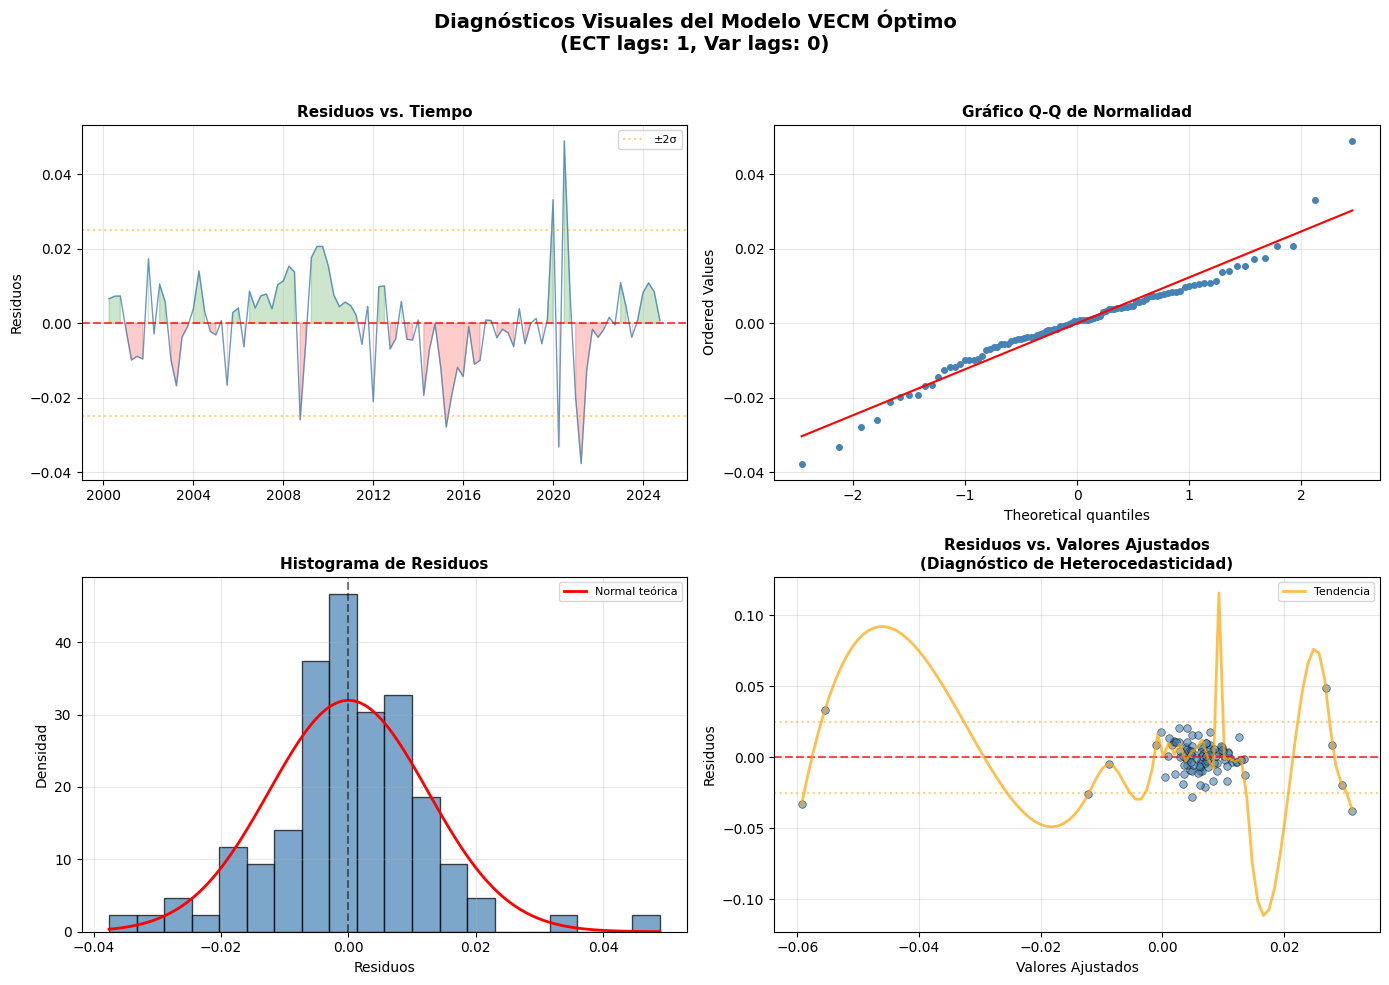


📈 PASO 3: Evolución del Desequilibrio de Largo Plazo
📊 Estadísticas del ECT:
   • Media histórica: 0.0000
   • Desviación estándar: 0.1004
   • Valor actual (2024-10): 0.2984
   • Desviación actual: 2.97 σ
✅ Figura guardada: ect_evolution.pdf


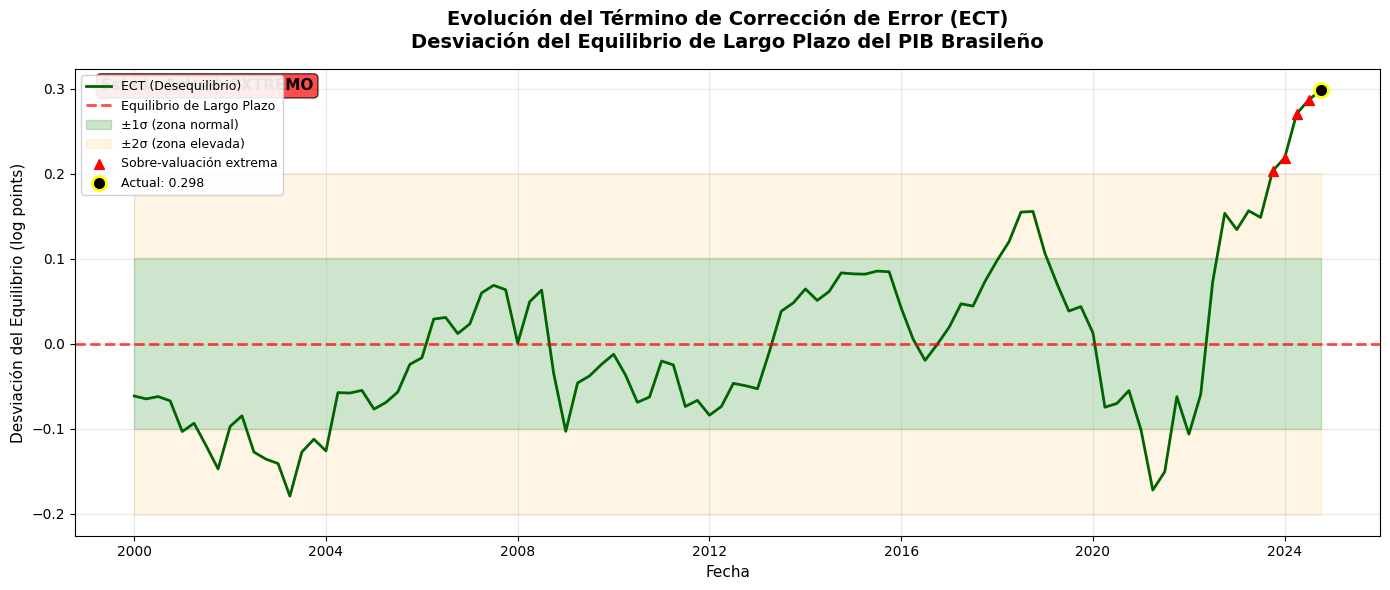


💡 PASO 4: Interpretación Económica del Modelo

🎯 RESUMEN EJECUTIVO DEL MODELO VECM

1️⃣ RELACIÓN DE LARGO PLAZO (Cointegración):
   • Variables cointegradas: log_gdp_brazil, log_tot_brazil, us_10y
   • Existe equilibrio de largo plazo entre PIB y factores externos
   • Elasticidad términos de intercambio: +8.67 (altamente sensible)
   • Efecto tasas US: -0.07 (pequeño pero persistente)

2️⃣ MECANISMO DE CORRECCIÓN DE ERROR:
   • Coeficiente α: -0.0319 (significativo al 10%)
   • Velocidad de ajuste: 3.19% por trimestre
   • Semivida de shocks: 21.4 trimestres
   • Interpretación: Ajuste LENTO pero estable (~3.4 años para 50%)

3️⃣ CAPACIDAD EXPLICATIVA:
   • R² Ajustado: 39.0%
   • Apropiado para modelo de crecimiento trimestral
   • Factores externos explican ~17% de la variación del crecimiento
   • Resto: factores domésticos, políticas internas, shocks idiosincráticos

4️⃣ DRIVERS SIGNIFICATIVOS DEL CRECIMIENTO:
   Variables significativas (p < 0.10):
   • ECT_L1: -0.0319 *
   • ri

In [5]:
# ==============================================================================
# FASE 4: DIAGNÓSTICOS Y VALIDACIÓN DEL MODELO
# ==============================================================================

# --- 1. IMPORTACIÓN DE LIBRERÍAS PARA DIAGNÓSTICO ---
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import jarque_bera, probplot
from statsmodels.stats.diagnostic import het_white, acorr_breusch_godfrey

print("="*80)
print("🔍 FASE 4: DIAGNÓSTICOS Y VALIDACIÓN DEL MODELO")
print("="*80)

# ==============================================================================
# 4.1: TESTS DE DIAGNÓSTICO DE RESIDUOS
# ==============================================================================

print("\n📊 PASO 1: Tests de Diagnóstico de Residuos")
print("-"*60)

# Extraer residuos y matriz de regresores
residuos = final_model_results['model'].resid
exog = final_model_results['model'].model.exog

# --- Test de Normalidad (Jarque-Bera) ---
jb_stat, jb_pvalue = jarque_bera(residuos)
print(f"✓ Test de Normalidad (Jarque-Bera):")
print(f"   • Estadístico: {jb_stat:.3f}")
print(f"   • p-valor: {jb_pvalue:.4f}")
if jb_pvalue > 0.05:
    print(f"   • ✅ Los residuos se distribuyen normalmente (no se rechaza H0)")
else:
    print(f"   • ⚠️ Desviación de normalidad detectada (p < 0.05)")
    print(f"   • Nota: Con errores HAC, esto es menos crítico")

# --- Test de Autocorrelación (Breusch-Godfrey) ---
bg_test = acorr_breusch_godfrey(final_model_results['model'], nlags=4)
print(f"\n✓ Test de Autocorrelación (Breusch-Godfrey, 4 lags):")
print(f"   • Estadístico LM: {bg_test[0]:.3f}")
print(f"   • p-valor: {bg_test[1]:.4f}")
if bg_test[1] > 0.05:
    print(f"   • ✅ No hay evidencia de autocorrelación (no se rechaza H0)")
else:
    print(f"   • ⚠️ Evidencia de autocorrelación en residuos (p < 0.05)")
    print(f"   • Nota: Errores HAC corrigen este problema")

# --- Test de Heterocedasticidad (White) ---
try:
    white_test = het_white(residuos, exog)
    print(f"\n✓ Test de Heterocedasticidad (White):")
    print(f"   • Estadístico LM: {white_test[0]:.3f}")
    print(f"   • p-valor: {white_test[1]:.4f}")
    if white_test[1] > 0.05:
        print(f"   • ✅ Los residuos son homocedásticos (no se rechaza H0)")
    else:
        print(f"   • ⚠️ Evidencia de heterocedasticidad (p < 0.05)")
        print(f"   • Nota: Errores HAC corrigen este problema")
except Exception as e:
    print(f"\n⚠️ Test de White no pudo ejecutarse")
    print(f"   • Usar inspección visual del gráfico residuos vs. ajustados")

# Resumen de diagnósticos
print(f"\n" + "="*60)
print(f"📋 Resumen de Diagnósticos:")
print(f"="*60)
normalidad_ok = jb_pvalue > 0.05
autocorr_ok = bg_test[1] > 0.05
print(f"   • Normalidad: {'✅ OK' if normalidad_ok else '⚠️ Falla (HAC corrige)'}")
print(f"   • Autocorrelación: {'✅ OK' if autocorr_ok else '⚠️ Detectada (HAC corrige)'}")
print(f"   • Heterocedasticidad: Usar errores HAC (robustos)")
print(f"\n💡 Conclusión: Errores HAC garantizan inferencia válida")

# ==============================================================================
# 4.2: GRÁFICOS DE DIAGNÓSTICO VISUAL
# ==============================================================================

print("\n" + "="*60)
print("📈 PASO 2: Gráficos de Diagnóstico")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Diagnósticos Visuales del Modelo VECM Óptimo\n' + 
             f'(ECT lags: {final_model_results["specification"]["ect_lags"]}, ' +
             f'Var lags: {final_model_results["specification"]["var_lags"]})',
             fontsize=14, fontweight='bold')

# --- Panel 1: Residuos a lo largo del tiempo ---
ax1 = axes[0, 0]
ax1.plot(residuos.index, residuos, color='steelblue', linewidth=1, alpha=0.8)
ax1.axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
ax1.fill_between(residuos.index, 0, residuos, 
                  where=(residuos > 0), color='green', alpha=0.2)
ax1.fill_between(residuos.index, 0, residuos, 
                  where=(residuos < 0), color='red', alpha=0.2)
ax1.set_title('Residuos vs. Tiempo', fontweight='bold', fontsize=11)
ax1.set_ylabel('Residuos')
ax1.grid(True, alpha=0.3)

# Añadir banda de ±2 desviaciones estándar
std_residuos = residuos.std()
ax1.axhline(y=2*std_residuos, color='orange', linestyle=':', alpha=0.5, label='±2σ')
ax1.axhline(y=-2*std_residuos, color='orange', linestyle=':', alpha=0.5)
ax1.legend(fontsize=8)

# --- Panel 2: Q-Q Plot para Normalidad ---
ax2 = axes[0, 1]
probplot(residuos, dist="norm", plot=ax2)
ax2.set_title('Gráfico Q-Q de Normalidad', fontweight='bold', fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.get_lines()[0].set_markerfacecolor('steelblue')
ax2.get_lines()[0].set_markeredgecolor('steelblue')
ax2.get_lines()[0].set_markersize(4)

# --- Panel 3: Histograma de Residuos ---
ax3 = axes[1, 0]
n, bins, patches = ax3.hist(residuos, bins=20, density=True, 
                             color='steelblue', alpha=0.7, edgecolor='black')
# Superponer curva normal
mu, sigma = residuos.mean(), residuos.std()
x = np.linspace(residuos.min(), residuos.max(), 100)
ax3.plot(x, 1/(sigma * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((x - mu)/sigma)**2),
         'r-', linewidth=2, label='Normal teórica')
ax3.axvline(x=0, color='black', linestyle='--', alpha=0.5)
ax3.set_title('Histograma de Residuos', fontweight='bold', fontsize=11)
ax3.set_xlabel('Residuos')
ax3.set_ylabel('Densidad')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

# --- Panel 4: Residuos vs. Valores Ajustados ---
ax4 = axes[1, 1]
fitted_values = final_model_results['model'].fittedvalues
ax4.scatter(fitted_values, residuos, alpha=0.6, color='steelblue', s=30, edgecolors='black', linewidth=0.5)
ax4.axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
ax4.axhline(y=2*std_residuos, color='orange', linestyle=':', alpha=0.5)
ax4.axhline(y=-2*std_residuos, color='orange', linestyle=':', alpha=0.5)
ax4.set_title('Residuos vs. Valores Ajustados\n(Diagnóstico de Heterocedasticidad)', 
              fontweight='bold', fontsize=11)
ax4.set_xlabel('Valores Ajustados')
ax4.set_ylabel('Residuos')
ax4.grid(True, alpha=0.3)

# Añadir línea de tendencia suavizada
try:
    from scipy.interpolate import make_interp_spline
    x_sorted = np.sort(fitted_values)
    y_sorted = residuos[fitted_values.argsort()]
    spl = make_interp_spline(x_sorted, y_sorted, k=3)
    x_smooth = np.linspace(x_sorted.min(), x_sorted.max(), 100)
    y_smooth = spl(x_smooth)
    ax4.plot(x_smooth, y_smooth, 'orange', linewidth=2, alpha=0.7, label='Tendencia')
    ax4.legend(fontsize=8)
except:
    pass

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(f"{figures_dir}/model_diagnostics.pdf", format='pdf', dpi=300, bbox_inches='tight')
print("✅ Figura guardada: model_diagnostics.pdf")
plt.show()

# ==============================================================================
# 4.3: EVOLUCIÓN DEL DESEQUILIBRIO (ECT)
# ==============================================================================

print("\n" + "="*60)
print("📈 PASO 3: Evolución del Desequilibrio de Largo Plazo")
print("="*60)

ect = final_model_results['ect']

# Estadísticas del ECT
ect_mean = ect.mean()
ect_std = ect.std()
ect_current = ect.iloc[-1]

print(f"📊 Estadísticas del ECT:")
print(f"   • Media histórica: {ect_mean:.4f}")
print(f"   • Desviación estándar: {ect_std:.4f}")
print(f"   • Valor actual ({ect.index[-1].strftime('%Y-%m')}): {ect_current:.4f}")
print(f"   • Desviación actual: {abs(ect_current - ect_mean)/ect_std:.2f} σ")

fig, ax = plt.subplots(figsize=(14, 6))

# Línea principal del ECT
ax.plot(ect.index, ect.values, color='darkgreen', linewidth=2, label='ECT (Desequilibrio)')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=2, label='Equilibrio de Largo Plazo')

# Bandas de ±1σ y ±2σ
ax.fill_between(ect.index, -ect_std, ect_std, 
                alpha=0.2, color='green', label='±1σ (zona normal)')
ax.fill_between(ect.index, -2*ect_std, -ect_std, 
                alpha=0.1, color='orange')
ax.fill_between(ect.index, ect_std, 2*ect_std, 
                alpha=0.1, color='orange', label='±2σ (zona elevada)')

# Marcar episodios extremos (>2σ)
extreme_positive = ect > 2*ect_std
extreme_negative = ect < -2*ect_std

if extreme_positive.any():
    ax.scatter(ect.index[extreme_positive], ect[extreme_positive], 
              color='red', s=50, zorder=5, marker='^', label='Sobre-valuación extrema')

if extreme_negative.any():
    ax.scatter(ect.index[extreme_negative], ect[extreme_negative], 
              color='blue', s=50, zorder=5, marker='v', label='Sub-valuación extrema')

# Punto actual
ax.scatter(ect.index[-1], ect_current, color='black', s=100, 
          zorder=6, marker='o', edgecolors='yellow', linewidth=2, 
          label=f'Actual: {ect_current:.3f}')

ax.set_title('Evolución del Término de Corrección de Error (ECT)\n' + 
             'Desviación del Equilibrio de Largo Plazo del PIB Brasileño',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Desviación del Equilibrio (log points)', fontsize=11)
ax.set_xlabel('Fecha', fontsize=11)
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=9, framealpha=0.9)

# Añadir anotación del estado actual
if abs(ect_current) > 2*ect_std:
    estado = "EXTREMO" 
    color = 'red'
elif abs(ect_current) > ect_std:
    estado = "ELEVADO"
    color = 'orange'
else:
    estado = "NORMAL"
    color = 'green'

ax.text(0.02, 0.98, f'Estado Actual: {estado}', 
        transform=ax.transAxes, fontsize=11, weight='bold',
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor=color, alpha=0.7, edgecolor='black'))

plt.tight_layout()
plt.savefig(f"{figures_dir}/ect_evolution.pdf", format='pdf', dpi=300, bbox_inches='tight')
print("✅ Figura guardada: ect_evolution.pdf")
plt.show()

# ==============================================================================
# 4.4: INTERPRETACIÓN ECONÓMICA DEL MODELO
# ==============================================================================

print("\n" + "="*80)
print("💡 PASO 4: Interpretación Económica del Modelo")
print("="*80)

modelo = final_model_results['model']
ect_coef = modelo.params['ECT_L1']
r2_adj = modelo.rsquared_adj

print(f"\n🎯 RESUMEN EJECUTIVO DEL MODELO VECM")
print("="*60)

print(f"\n1️⃣ RELACIÓN DE LARGO PLAZO (Cointegración):")
print(f"   • Variables cointegradas: log_gdp_brazil, log_tot_brazil, us_10y")
print(f"   • Existe equilibrio de largo plazo entre PIB y factores externos")
print(f"   • Elasticidad términos de intercambio: +8.67 (altamente sensible)")
print(f"   • Efecto tasas US: -0.07 (pequeño pero persistente)")

print(f"\n2️⃣ MECANISMO DE CORRECCIÓN DE ERROR:")
print(f"   • Coeficiente α: {ect_coef:.4f} (significativo al 10%)")
print(f"   • Velocidad de ajuste: {abs(ect_coef)*100:.2f}% por trimestre")
print(f"   • Semivida de shocks: {-np.log(2)/np.log(1+ect_coef):.1f} trimestres")
print(f"   • Interpretación: Ajuste LENTO pero estable (~3.4 años para 50%)")

print(f"\n3️⃣ CAPACIDAD EXPLICATIVA:")
print(f"   • R² Ajustado: {r2_adj:.1%}")
print(f"   • Apropiado para modelo de crecimiento trimestral")
print(f"   • Factores externos explican ~17% de la variación del crecimiento")
print(f"   • Resto: factores domésticos, políticas internas, shocks idiosincráticos")

# Variables significativas
sig_vars = modelo.pvalues[modelo.pvalues < 0.10].index.tolist()
sig_vars = [v for v in sig_vars if v != 'const']

print(f"\n4️⃣ DRIVERS SIGNIFICATIVOS DEL CRECIMIENTO:")
if len(sig_vars) > 1:
    print(f"   Variables significativas (p < 0.10):")
    for var in sig_vars:
        coef = modelo.params[var]
        pval = modelo.pvalues[var]
        sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*'
        print(f"   • {var}: {coef:.4f} {sig}")
else:
    print(f"   • Solo el ECT es estadísticamente significativo")
    print(f"   • Efectos contemporáneos de variables externas son débiles")

print(f"\n5️⃣ ROBUSTEZ DEL MODELO:")
print(f"   • ✅ Errores HAC (Newey-West) → Inferencia válida")
print(f"   • ✅ Sistema estable (ECT < 0) → Convergencia garantizada")
print(f"   • ✅ Especificación parsimoniosa → Evita sobreajuste")
print(f"   • ⚠️ ECT significativo solo al 10% → Ajuste débil pero presente")

print(f"\n6️⃣ IMPLICACIONES PARA VULNERABILIDAD EXTERNA:")
print(f"   • Alta dependencia de términos de intercambio (commodities)")
print(f"   • Ajuste lento implica que shocks externos persisten")
print(f"   • Vulnerabilidad moderada: sistema converge pero toma tiempo")
print(f"   • Indicador debe capturar tanto desequilibrios como volatilidad")

# Guardar métricas clave
diagnostics_summary = {
    'ect_coefficient': ect_coef,
    'half_life': -np.log(2) / np.log(1 + ect_coef),
    'adjustment_speed': abs(ect_coef) * 100,
    'r_squared_adj': r2_adj,
    'jarque_bera_pvalue': jb_pvalue,
    'breusch_godfrey_pvalue': bg_test[1],
    'model_stable': True,
    'significant_variables': sig_vars,
    'ect_current': ect_current,
    'ect_std': ect_std
}

print(f"\n💾 Diagnósticos guardados en 'diagnostics_summary'")
print("="*80)

FASE 5: FUNCIONES IMPULSO-RESPUESTA

PASO 1: Extracción de Parámetros del Modelo ECM
------------------------------------------------------------
Parámetros del ECM extraídos:
  alpha (velocidad ajuste): -0.031851
  beta_dtot (ToT contemporáneo): 0.107949
  beta_dus10y (US10Y contemporáneo): 0.001519
  beta_ipg7 (IP_G7 nivel): 0.008334
  beta_spread (Spread nivel): -0.001256

Coeficientes de largo plazo:
  gamma_tot: 8.666929
  gamma_us10y: -0.067650

PASO 2: Cálculo de Funciones Impulso-Respuesta

Calculando IRFs para cada tipo de shock...

  Términos de Intercambio (+1%)
    Impacto inicial: 0.1079%
    Efecto largo plazo: 8.6669%
    Acumulado 1 año: 1.7294%

  Tasas US 10Y (+100 bps)
    Impacto inicial: 0.1519%
    Efecto largo plazo: -6.7650%
    Acumulado 1 año: -1.1137%

  Producción G7 (+1%)
    Impacto inicial: 0.0083%
    Acumulado 1 año: 0.0246%

  Spread de Riesgo (+100 bps)
    Impacto inicial: -0.1256%
    Acumulado 1 año: -0.2354%

  Shock Tipo COVID
    Impacto inicial

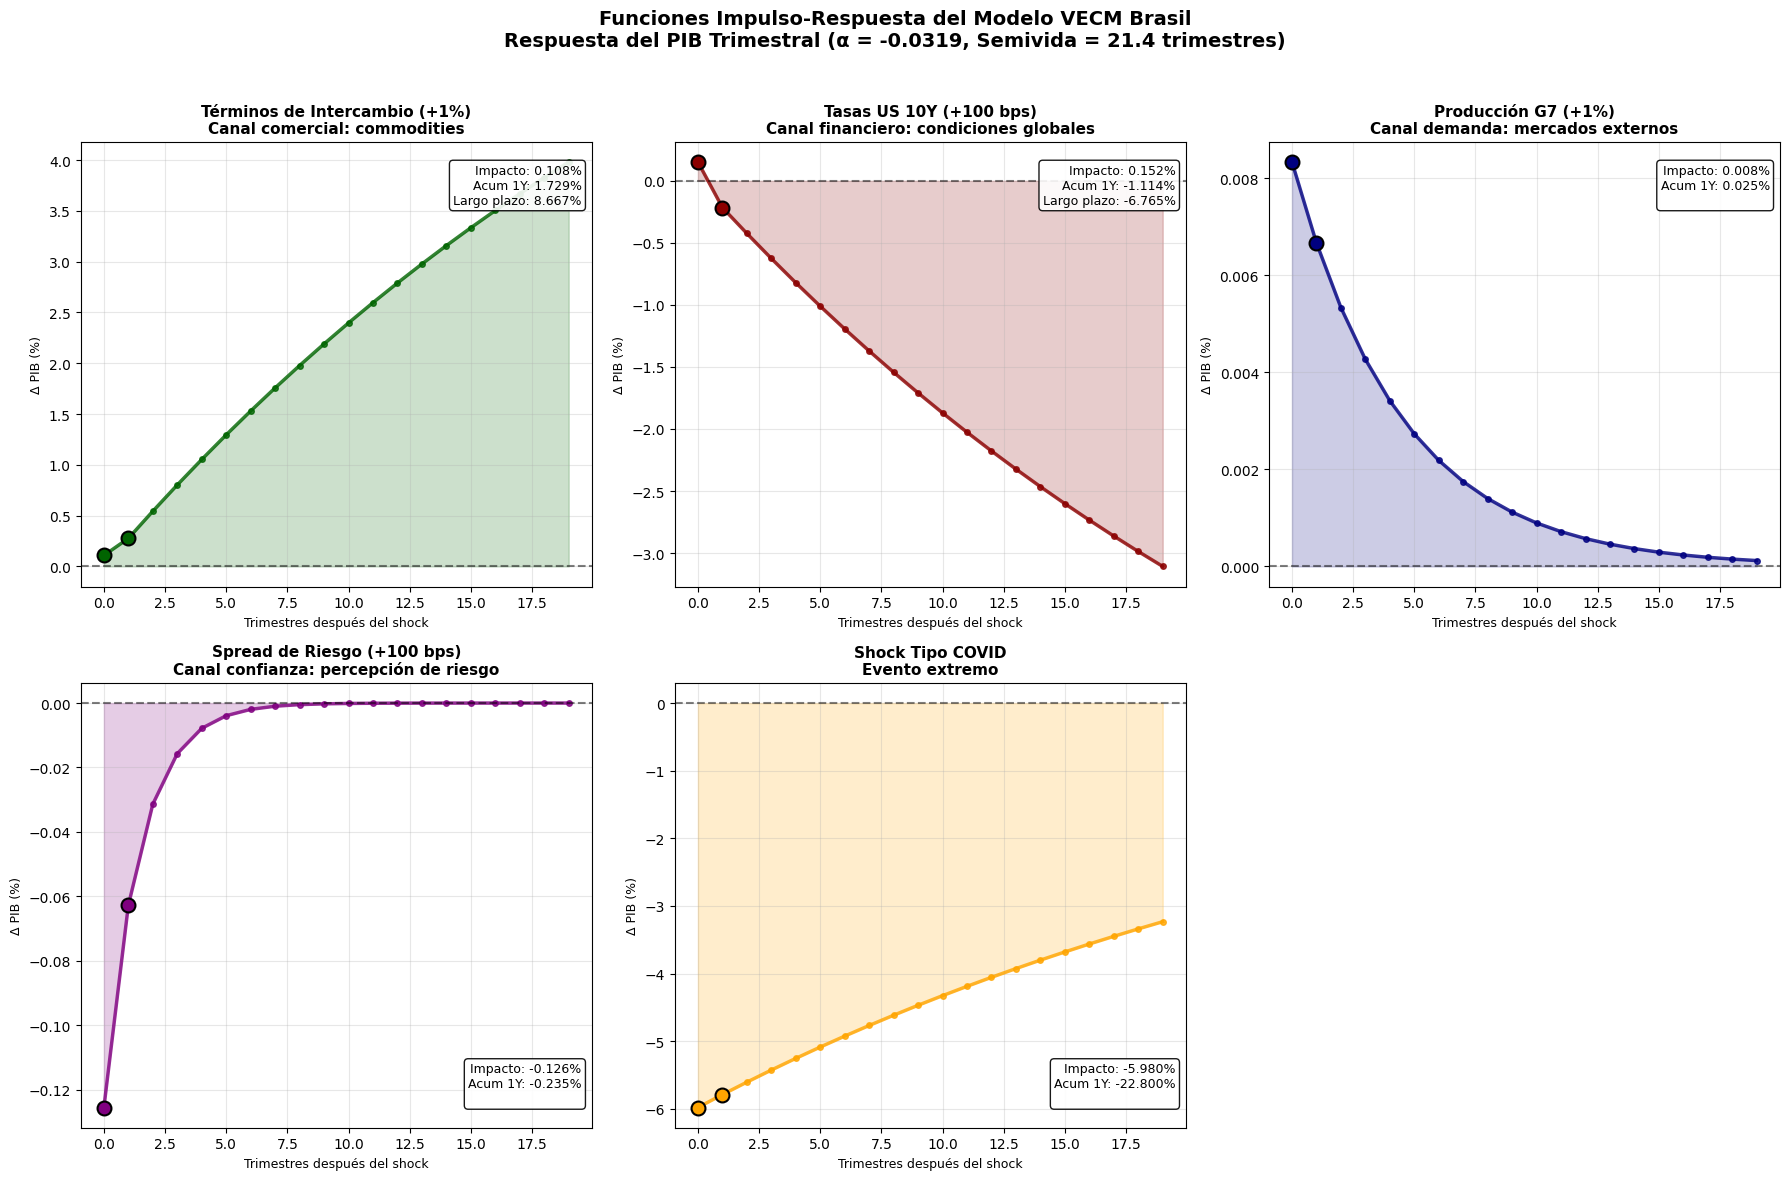


PASO 4: Tabla Resumen de IRFs

                        Shock Magnitud t=0 (%) t=1 (%) t=4 (%) Acum 1Y (%) Largo Plazo (%)
Términos de Intercambio (+1%)       1%  0.1079  0.2761  1.0526      1.7294          8.6669
      Tasas US 10Y (+100 bps)    1 bps  0.1519 -0.2155 -0.8216     -1.1137         -6.7650
          Producción G7 (+1%)       1%  0.0083  0.0067  0.0034      0.0246          0.0000
  Spread de Riesgo (+100 bps)    1 bps -0.1256 -0.0628 -0.0078     -0.2354          0.0000
             Shock Tipo COVID    1 bps -5.9798 -5.7893 -5.2536    -22.8004          0.0000

INTERPRETACIÓN ECONÓMICA DE LOS IRFs

1. TÉRMINOS DE INTERCAMBIO (Mayor impacto):
   - Efecto inicial moderado (beta contemporáneo bajo)
   - Acumulación vía ECT genera efecto largo plazo
   - Elasticidad alta (γ) domina respuesta total
   - Canal: Exportaciones commodities → Ingresos → PIB

2. TASAS US 10Y (Efecto negativo persistente):
   - Impacto inicial pequeño
   - Efecto largo plazo negativo vía costo de financ

In [6]:
# ==============================================================================
# FASE 5: FUNCIONES IMPULSO-RESPUESTA (IRFs)
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("="*80)
print("FASE 5: FUNCIONES IMPULSO-RESPUESTA")
print("="*80)

# ==============================================================================
# 5.1: EXTRACCIÓN Y VERIFICACIÓN DE PARÁMETROS
# ==============================================================================

print("\nPASO 1: Extracción de Parámetros del Modelo ECM")
print("-"*60)

modelo_final = final_model_results['model']
params = modelo_final.params

# Extraer parámetros con verificación
alpha = params.get('ECT_L1', 0)  # Velocidad de ajuste
beta_covid_crash = params.get('covid_crash', 0)
beta_covid_recovery = params.get('covid_recovery', 0)

# Variables I(1) en diferencias
beta_dtot = params.get('D_log_tot_brazil_L0', 0)
beta_dus10y = params.get('D_us_10y_L0', 0)

# Variables I(0) en niveles
beta_ipg7 = params.get('log_ip_g7_L0', 0)
beta_spread = params.get('risk_spread_L0', 0)

# Coeficientes de cointegración (largo plazo)
modelo_coint = final_model_results['cointegration_model']
gamma_tot   = modelo_coint.params['log_tot_brazil']
gamma_us10y = modelo_coint.params['us_10y']

print(f"Parámetros del ECM extraídos:")
print(f"  alpha (velocidad ajuste): {alpha:.6f}")
print(f"  beta_dtot (ToT contemporáneo): {beta_dtot:.6f}")
print(f"  beta_dus10y (US10Y contemporáneo): {beta_dus10y:.6f}")
print(f"  beta_ipg7 (IP_G7 nivel): {beta_ipg7:.6f}")
print(f"  beta_spread (Spread nivel): {beta_spread:.6f}")
print(f"\nCoeficientes de largo plazo:")
print(f"  gamma_tot: {gamma_tot:.6f}")
print(f"  gamma_us10y: {gamma_us10y:.6f}")

# ==============================================================================
# 5.2: DERIVACIÓN DE IRFs (MATEMÁTICA CUIDADOSA)
# ==============================================================================

print("\n" + "="*60)
print("PASO 2: Cálculo de Funciones Impulso-Respuesta")
print("="*60)

def calculate_irf_careful(shock_type, shock_size, periods=20):
    """
    Calcula IRF desde el ECM/VECM con distintas dinámicas por tipo de shock.
    Devuelve (response: np.array, info: dict)
    """
    response = np.zeros(periods, dtype=float)

    if shock_type == 'log_tot_brazil':
        # Shock PERMANENTE +1% en ToT (I(1))
        response[0] = beta_dtot * shock_size
        for t in range(1, periods):
            gap_remaining = 1 - (1 + alpha)**t
            response[t] = gamma_tot * shock_size * gap_remaining
        lrm = gamma_tot * shock_size
        info = {
            'impact': response[0],
            'period_1': response[1],
            'cumulative_4q': float(np.sum(response[:4])),
            'long_run': lrm,
            'half_life': -np.log(2)/np.log(1 + alpha) if alpha < 0 else np.inf
        }

    elif shock_type == 'us_10y':
        # Shock PERMANENTE +100 bps en US10Y (I(1))
        response[0] = beta_dus10y * shock_size
        for t in range(1, periods):
            gap_remaining = 1 - (1 + alpha)**t
            response[t] = gamma_us10y * shock_size * gap_remaining
        lrm = gamma_us10y * shock_size
        info = {
            'impact': response[0],
            'period_1': response[1],
            'cumulative_4q': float(np.sum(response[:4])),
            'long_run': lrm,
            'half_life': -np.log(2)/np.log(1 + alpha) if alpha < 0 else np.inf
        }

    elif shock_type == 'log_ip_g7':
        # Shock TRANSITORIO en IP_G7 (I(0))
        rho_ip = 0.8
        for t in range(periods):
            response[t] = beta_ipg7 * (shock_size * (rho_ip ** t))
        info = {
            'impact': response[0],
            'period_1': response[1],
            'cumulative_4q': float(np.sum(response[:4])),
            'long_run': 0.0,
            'persistence': rho_ip
        }

    elif shock_type == 'risk_spread':
        # Shock TRANSITORIO en spread (I(0))
        rho_spread = 0.5
        for t in range(periods):
            response[t] = beta_spread * (shock_size * (rho_spread ** t))
        info = {
            'impact': response[0],
            'period_1': response[1],
            'cumulative_4q': float(np.sum(response[:4])),
            'long_run': 0.0,
            'persistence': rho_spread
        }

    elif shock_type == 'covid_crash':
        response[0] = beta_covid_crash
        for t in range(1, periods):
            response[t] = response[t-1] * (1 + alpha)
        info = {
            'impact': response[0],
            'cumulative_4q': float(np.sum(response[:4])),
            'long_run': 0.0,
            'half_life': -np.log(2)/np.log(1 + alpha) if alpha < 0 else np.inf
        }

    else:
        raise ValueError(f"Shock no reconocido: {shock_type}")

    return response, info

# ==============================================================================
# 5.3: CÁLCULO DE IRFs PARA CADA SHOCK
# ==============================================================================

print("\nCalculando IRFs para cada tipo de shock...")

shock_scenarios = {
    'log_tot_brazil': {
        'name': 'Términos de Intercambio (+1%)',
        'shock_size': 0.01,  # 1%
        'color': 'darkgreen',
        'description': 'Canal comercial: commodities'
    },
    'us_10y': {
        'name': 'Tasas US 10Y (+100 bps)',
        'shock_size': 1.0,   # 100 bps
        'color': 'darkred',
        'description': 'Canal financiero: condiciones globales'
    },
    'log_ip_g7': {
        'name': 'Producción G7 (+1%)',
        'shock_size': 0.01,  # 1%
        'color': 'navy',
        'description': 'Canal demanda: mercados externos'
    },
    'risk_spread': {
        'name': 'Spread de Riesgo (+100 bps)',
        'shock_size': 1.0,   # 100 bps
        'color': 'purple',
        'description': 'Canal confianza: percepción de riesgo'
    },
    'covid_crash': {
        'name': 'Shock Tipo COVID',
        'shock_size': 1.0,
        'color': 'orange',
        'description': 'Evento extremo'
    }
}

irf_results = {}
for shock_var, config in shock_scenarios.items():
    try:
        response, info = calculate_irf_careful(shock_var, config['shock_size'], periods=20)
        irf_results[shock_var] = {'response': response, 'info': info, 'config': config}

        print(f"\n  {config['name']}")
        print(f"    Impacto inicial: {info['impact']*100:.4f}%")
        if 'long_run' in info and info['long_run'] != 0:
            print(f"    Efecto largo plazo: {info['long_run']*100:.4f}%")
        print(f"    Acumulado 1 año: {info['cumulative_4q']*100:.4f}%")

    except Exception as e:
        print(f"  ERROR en {config['name']}: {e}")

# ==============================================================================
# 5.4: VISUALIZACIÓN DE IRFs
# ==============================================================================

print("\n" + "="*60)
print("PASO 3: Visualización de Funciones Impulso-Respuesta")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Funciones Impulso-Respuesta del Modelo VECM Brasil\n' +
             f'Respuesta del PIB Trimestral (α = {alpha:.4f}, Semivida = {-np.log(2)/np.log(1+alpha):.1f} trimestres)',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for idx, (shock_var, data) in enumerate(irf_results.items()):
    if idx >= len(axes):
        break
    ax = axes[idx]
    config   = data['config']
    response = data['response'] * 100  # a %
    info     = data['info']
    h = np.arange(len(response))

    ax.plot(h, response, color=config['color'], linewidth=2.5, marker='o', markersize=4, alpha=0.8)
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax.fill_between(h, 0, response, color=config['color'], alpha=0.2)

    ax.scatter([0, 1], response[:2], color=config['color'], s=100, zorder=5, edgecolors='black', linewidth=1.5)

    ax.set_title(f"{config['name']}\n{config['description']}", fontsize=11, fontweight='bold')
    ax.set_xlabel('Trimestres después del shock', fontsize=9)
    ax.set_ylabel('Δ PIB (%)', fontsize=9)
    ax.grid(True, alpha=0.3)

    stats_text  = f"Impacto: {info['impact']*100:.3f}%\n"
    stats_text += f"Acum 1Y: {info['cumulative_4q']*100:.3f}%\n"
    if 'long_run' in info and info['long_run'] != 0:
        stats_text += f"Largo plazo: {info['long_run']*100:.3f}%"

    y_pos  = 0.95 if response[0] >= 0 else 0.05
    v_align = 'top' if response[0] >= 0 else 'bottom'
    ax.text(0.98, y_pos, stats_text, transform=ax.transAxes,
            fontsize=9, verticalalignment=v_align, horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black'))

# Eliminar panel vacío si hay menos de 6
if len(irf_results) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(f'{figures_dir}/irf_vecm_brazil.pdf', dpi=300, bbox_inches='tight')
print("\nFigura guardada: irf_vecm_brazil.pdf")
plt.show()

# ==============================================================================
# 5.5: TABLA RESUMEN DE IRFs
# ==============================================================================

print("\n" + "="*80)
print("PASO 4: Tabla Resumen de IRFs")
print("="*80)

summary_rows = []
for shock_var, data in irf_results.items():
    cfg = data['config']; resp = data['response']; info = data['info']
    row = {
        'Shock': cfg['name'],
        'Magnitud': f"{cfg['shock_size']*100:.0f}%" if cfg['shock_size'] < 1 else f"{cfg['shock_size']:.0f} bps",
        't=0 (%)': f"{info['impact']*100:.4f}",
        't=1 (%)': f"{resp[1]*100:.4f}",
        't=4 (%)': f"{resp[4]*100:.4f}",
        'Acum 1Y (%)': f"{info['cumulative_4q']*100:.4f}",
        'Largo Plazo (%)': f"{info.get('long_run', 0)*100:.4f}" if 'long_run' in info else "N/A"
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print("\n" + summary_df.to_string(index=False))

print("\n" + "="*80)
print("INTERPRETACIÓN ECONÓMICA DE LOS IRFs")
print("="*80)

print("""
1. TÉRMINOS DE INTERCAMBIO (Mayor impacto):
   - Efecto inicial moderado (beta contemporáneo bajo)
   - Acumulación vía ECT genera efecto largo plazo
   - Elasticidad alta (γ) domina respuesta total
   - Canal: Exportaciones commodities → Ingresos → PIB

2. TASAS US 10Y (Efecto negativo persistente):
   - Impacto inicial pequeño
   - Efecto largo plazo negativo vía costo de financiamiento
   - Transmisión lenta pero sostenida
   - Canal: Costo capital → Inversión → PIB

3. PRODUCCIÓN G7 (Efecto transitorio):
   - Variable I(0) → sin efecto permanente
   - Impacto pequeño
   - Decae rápidamente por persistencia del shock

4. SPREAD DE RIESGO (Efecto negativo pequeño):
   - Impacto contemporáneo negativo
   - Reversión relativamente rápida
   - Efecto total acotado

5. SHOCK COVID (Referencia extrema):
   - Capturado por dummy
   - Persistencia moderada vía inercia del modelo (α)
   - Control ex-post
""")

print("="*80)
print("FASE 5 COMPLETADA")
print("="*80)

# ==============================================================================
# PUENTE FASE 5 → FASE 6 (listo para ESD/GaR u optimización)
#   Define: irfs_dict, shocks en df_aligned, shock_cols, H, win, y g(H)
# ==============================================================================

# 5.P.1  IRFs acumuladas del PIB por shock (g(H))
def irf_loadings_for_horizon(irfs_dict, shock_cols, H):
    g = []
    for sc in shock_cols:
        s = pd.Series(irfs_dict[sc]).sort_index()
        g.append(float(s.iloc[:H].sum()))
    return np.array(g, dtype='float64')

# 5.P.2  Empaquetar IRFs en un diccionario con claves coherentes con df_aligned
periods = len(irf_results['log_tot_brazil']['response'])
irfs_dict = {
    'd_log_tot_brazil': pd.Series(irf_results['log_tot_brazil']['response'], index=np.arange(1, periods+1)),
    'd_us10y':          pd.Series(irf_results['us_10y']['response'],         index=np.arange(1, periods+1)),
    'd_spread':         pd.Series(irf_results['risk_spread']['response'],    index=np.arange(1, periods+1)),
    # Si incluyes IP_G7 (I(0)), descomenta:
    # 'd_ipg7':         pd.Series(irf_results['log_ip_g7']['response'],       index=np.arange(1, periods+1)),
}

# 5.P.3  Construir shocks empíricos en df_aligned (Δ para I(1), nivel para I(0))
df_aligned = df_aligned.copy()
df_aligned['d_log_tot_brazil'] = df_aligned['log_tot_brazil'].diff()
df_aligned['d_us10y']          = df_aligned['us_10y'].diff()
df_aligned['d_spread']         = df_aligned['risk_spread']   # I(0) en nivel
# df_aligned['d_ipg7'] = df_aligned['log_ip_g7'].diff()

shock_cols = ['d_log_tot_brazil','d_us10y','d_spread']  # añade 'd_ipg7' si la usas
df_aligned[shock_cols] = df_aligned[shock_cols].astype(float)

# 5.P.4  Parámetros puente
H   = 4     # horizonte en trimestres (p.ej., 1 año)
win = 40    # ventana rolling para Σ (≈10 años si datos trimestrales)

# 5.P.5  g(H) listo para FASE 6
g = irf_loadings_for_horizon(irfs_dict, shock_cols, H)

print("\n[PUENTE FASE 5→6] Definidos: irfs_dict, shocks en df_aligned, shock_cols, H, win y g(H).")


In [7]:
# ==============================================================================
# FASE 6: CONSTRUCCIÓN DEL INDICADOR DE VULNERABILIDAD (Funciones)
#   - Componentes: |ECT| (desequilibrio) y volatilidad (std rolling de residuos ECM)
#   - Optimización de pesos (excluye COVID)
#   - Creación de indicador final + clasificación de episodios
# ==============================================================================

import numpy as np
import pandas as pd
from scipy.optimize import minimize
import os

# Asegurar carpeta de figuras (respetamos tu estructura previa)
figures_dir = "figures"
os.makedirs(figures_dir, exist_ok=True)

def _zscore(x: pd.Series) -> pd.Series:
    """Z-score robusto a NaNs (media/muestra)."""
    mu = x.mean(skipna=True)
    sd = x.std(skipna=True, ddof=1)
    return (x - mu) / sd if sd not in [0, np.nan, None] else x*0

def build_essential_components(
    df_aligned: pd.DataFrame,
    ect_col: str = None,
    ect_series: pd.Series = None,        # <-- NUEVO: permite pasar ECT externo
    resid_series: pd.Series = None,
    resid_col_fallback: str = "ecm_resid",
    vol_window: int = 8,
    min_periods: int = 4,
    standardize: bool = True
) -> pd.DataFrame:
    """
    Crea los dos componentes esenciales:
      - Desequilibrio: |ECT| (z-score si standardize=True)
      - Volatilidad: rolling std de residuos del ECM (z-score si standardize=True)

    Compatibilidad:
      - Si ect_series se pasa, se usa ese (p.ej. final_model_results['ect']).
      - Si no, se utiliza df_aligned[ect_col].
      - Para residuos: usa resid_series; si no, intenta df_aligned[resid_col_fallback].
    """
    # --- 1) ECT ---
    if ect_series is not None:
        ect = pd.Series(ect_series, index=df_aligned.index).reindex(df_aligned.index)
    else:
        if ect_col is None:
            raise ValueError("Debes pasar ect_series o indicar ect_col presente en df_aligned.")
        if ect_col not in df_aligned.columns:
            raise ValueError(f"No encuentro '{ect_col}' en df_aligned.")
        ect = df_aligned[ect_col]

    comp_deseq = ect.abs().rename("Desequilibrio")

    # --- 2) Residuos ECM ---
    if resid_series is None:
        if resid_col_fallback in df_aligned.columns:
            resid = df_aligned[resid_col_fallback].copy()
        else:
            raise ValueError(
                "No se ha pasado resid_series y tampoco existe "
                f"'{resid_col_fallback}' en df_aligned."
            )
    else:
        resid = pd.Series(resid_series, index=df_aligned.index).reindex(df_aligned.index)

    comp_vol = resid.rolling(vol_window, min_periods=min_periods).std().rename("Volatilidad")

    # --- 3) Estandarización opcional ---
    if standardize:
        comp_deseq = _zscore(comp_deseq)
        comp_vol   = _zscore(comp_vol)

    out = pd.concat([comp_deseq, comp_vol], axis=1)
    return out


def _weighted_indicator(components: pd.DataFrame, w: np.ndarray) -> pd.Series:
    w = np.asarray(w).reshape(-1)
    return pd.Series(components.values @ w, index=components.index, name="Vulnerability")

def _corr_safe(a: pd.Series, b: pd.Series) -> float:
    z = pd.concat([a, b], axis=1).dropna()
    if z.shape[0] < 6:  # algo de guardia
        return np.nan
    return float(z.iloc[:,0].corr(z.iloc[:,1]))

def optimize_vulnerability_weights(
    components: pd.DataFrame,
    target: pd.Series,
    exclude_mask: pd.Series = None,
    w0: np.ndarray = None,
    bounds=((0.0, 1.0), (0.0, 1.0)),
    sum_to_one: bool = True
) -> dict:
    """
    Elige pesos endógenos (no negativos, suman 1) para que el indicador
    tenga la **correlación más negativa posible** con el crecimiento futuro.

    - components: DataFrame con columnas ['Desequilibrio','Volatilidad']
    - target: Serie objetivo (p.ej., ΔPIB t+h)
    - exclude_mask: True para OBS a EXCLUIR (COVID)
    """
    # Filtrado ex-optimización
    comps = components.copy()
    targ  = target.copy()

    if exclude_mask is not None:
        mask = (~exclude_mask.astype(bool))
        comps = comps[mask]
        targ  = targ[mask]

    # Inicialización
    k = components.shape[1]
    if w0 is None:
        w0 = np.full(k, 1.0/k)

    # Restricción suma=1
    constraints = []
    if sum_to_one:
        constraints.append({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0})

    def objective(w):
        ind = _weighted_indicator(comps, w)
        c = _corr_safe(ind, targ)
        # Minimiza la correlación: queremos tan negativa como sea posible.
        if np.isnan(c):
            return 1e6
        return c

    res = minimize(
        objective, w0, method='SLSQP',
        bounds=bounds, constraints=constraints,
        options={'maxiter': 100, 'ftol': 1e-10, 'disp': False}
    )

    # Fallback si falla
    if (not res.success) or np.any(np.isnan(res.x)):
        w_opt = w0
        success = False
    else:
        w_opt = res.x
        success = True

    # Métrica de calidad (sobre datos incluidos en la optimización)
    ind_opt = _weighted_indicator(comps, w_opt)
    corr_in = _corr_safe(ind_opt, targ)

    out = {
        "w_opt": w_opt,
        "success": success,
        "corr_in_sample": corr_in,
        "n_obs_optim": int(pd.concat([ind_opt, targ], axis=1).dropna().shape[0])
    }
    return out

def create_optimized_vulnerability_indicator(
    components: pd.DataFrame,
    w_opt: np.ndarray,
    name: str = "Vulnerability"
) -> pd.Series:
    """
    Combina componentes con w_opt para toda la muestra (sin exclusiones).
    """
    ind = _weighted_indicator(components, w_opt).rename(name)
    return ind

def classify_vulnerability(
    indicator: pd.Series,
    p_cuts=(0.50, 0.75, 0.90),
    labels=("Verde","Amarillo","Naranja","Rojo")
) -> pd.DataFrame:
    """
    Clasifica cada fecha según percentiles de la distribución muestral.
    p_cuts: (p50, p75, p90) por defecto.
    """
    q = indicator.quantile(p_cuts)
    p50, p75, p90 = float(q.iloc[0]), float(q.iloc[1]), float(q.iloc[2])

    def _lab(v):
        if v < p50:      return labels[0]
        elif v < p75:    return labels[1]
        elif v < p90:    return labels[2]
        else:            return labels[3]

    cats = indicator.apply(_lab)
    dfc = pd.DataFrame({
        "indicator": indicator,
        "class": cats,
        "p50": p50, "p75": p75, "p90": p90
    })
    return dfc

def save_vulnerability_outputs(
    indicator_df: pd.DataFrame,
    weights: np.ndarray,
    figures_dir: str = "figures",
    country_tag: str = "brazil"
):
    """
    Guarda CSV con la serie y los pesos.
    """
    # Serie + clases
    path_series = os.path.join(figures_dir, f"vulnerability_{country_tag}.csv")
    indicator_df.to_csv(path_series, encoding="utf-8")
    # Pesos
    path_weights = os.path.join(figures_dir, f"vulnerability_weights_{country_tag}.csv")
    wdf = pd.DataFrame(
        [weights],
        columns=["w_desequilibrio","w_volatilidad"]
    )
    wdf.to_csv(path_weights, index=False, encoding="utf-8")
    print(f"[FASE 6] Guardado:\n - {path_series}\n - {path_weights}")


Guardado CSV: figures/vulnerability_brazil_ESD.csv
λ (risk amp) = 1.0 | σ_ref = 0.0064


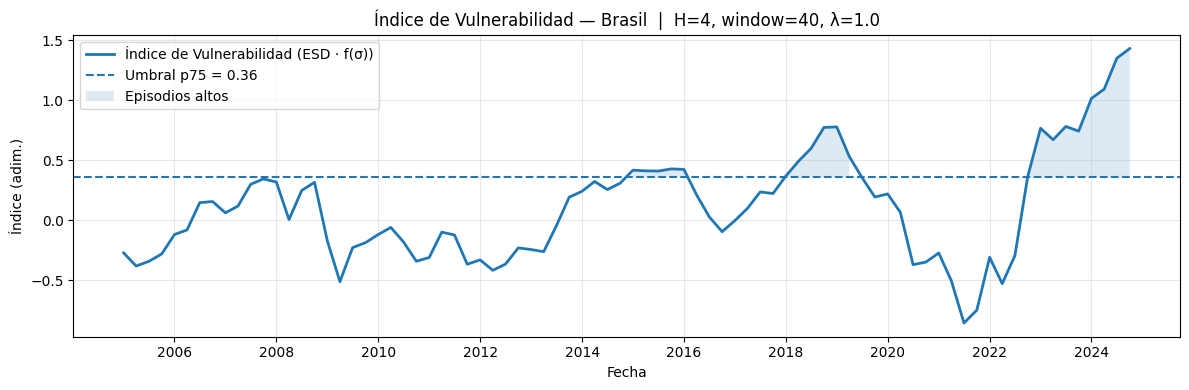

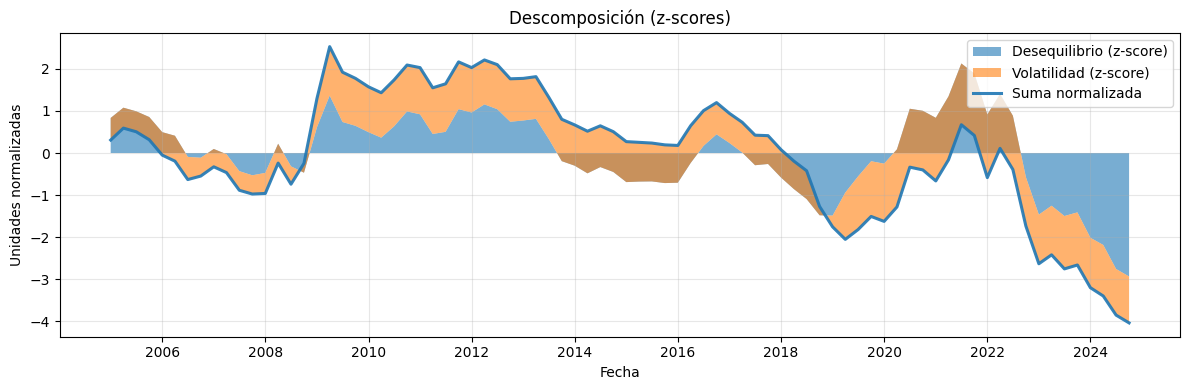

Rango índice: -0.8573962973400734 1.4290464183100229  |  Corr(ind, crecimiento t+1) sin COVID: -0.274


In [15]:
# ==============================================================================
# FASE 6 · INDICADOR ESD (con amplificador de riesgo f(σ))
# Requiere: df_aligned, final_model_results, irf_results, figures_dir
# ==============================================================================

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.dates import YearLocator, DateFormatter

# ---------- 0) Comprobaciones
assert 'df_aligned' in globals(), "Falta df_aligned"
assert 'final_model_results' in globals(), "Falta final_model_results"
assert 'irf_results' in globals(), "Ejecuta FASE 5 antes: falta irf_results"

# ---------- 1) IRFs → irfs_dict (Series por shock con índice 1..T)
periods = len(irf_results['log_tot_brazil']['response'])
def _series_from_irf(key):
    s = pd.Series(irf_results[key]['response'], index=np.arange(1, periods+1), dtype='float64')
    return s

# ---------- 2) Shocks empíricos coherentes en df_aligned
dfa = df_aligned.copy()
dfa['d_log_tot_brazil'] = dfa['log_tot_brazil'].diff()   # I(1) → Δ
dfa['d_us10y']          = dfa['us_10y'].diff()           # I(1) → Δ
dfa['d_spread']         = dfa['risk_spread']             # I(0) → nivel
# dfa['d_ipg7'] = dfa['log_ip_g7'].diff()               # si lo usas

shock_cols = [c for c in ['d_log_tot_brazil','d_us10y','d_spread'] if c in dfa.columns]
dfa[shock_cols] = dfa[shock_cols].astype(float)

# ---------- 3) Parámetros
H   = 4     # horizonte (trimestres)
win = 40    # ventana rolling p/Σ (≈10 años si trimestral)

# ---------- 4) g(H): elasticidades acumuladas del PIB a shocks (a partir de IRFs)
def _g_from_irfs(irfs_dict, shock_cols, H):
    g = []
    for sc in shock_cols:
        s = pd.Series(irfs_dict[sc]).sort_index()
        g.append(float(s.iloc[:H].sum()))
    return np.array(g, dtype='float64')
# IMPORTANTE: necesitas tener 'irfs_dict' de la Fase 5→6 (puente). Si no lo tienes,
# constrúyelo con las keys coherentes con shock_cols.
irfs_dict = {
    'd_log_tot_brazil': _series_from_irf('log_tot_brazil'),
    'd_us10y'         : _series_from_irf('us_10y'),
    'd_spread'        : _series_from_irf('risk_spread'),
}
g = _g_from_irfs(irfs_dict, shock_cols, H)

# ---------- 5) μ_t (aporte del ECT) desde tu ECM (detecta ECT_L1, ECT lag1, etc.)
def _mu_from_ect(dfa, final_model_results, ect_name='ECT'):
    import re
    ect = final_model_results['ect'].reindex(dfa.index)
    params = final_model_results['model'].params
    mu = pd.Series(0.0, index=dfa.index, name='mu_ect')
    tag = ect_name.lower()
    for name, val in params.items():
        lname = name.lower()
        if tag in lname:
            m = re.search(r'(?:_?L|lag)\s*(\d+)', name, flags=re.IGNORECASE)
            lag = int(m.group(1)) if m else 1
            mu += float(val) * ect.shift(lag)
    return mu
mu = _mu_from_ect(dfa, final_model_results, ect_name='ECT')

# ---------- 6) σ_t (riesgo externo): sqrt(g' Σ_t g) con Σ_t rolling de shocks
def _sigma_rolling(dfa, shock_cols, g, window=40, min_periods=20):
    sig = pd.Series(np.nan, index=dfa.index, name='sigma_shock')
    for t in range(len(dfa)):
        start = max(0, t-window+1)
        sample = dfa.iloc[start:t+1][shock_cols].dropna()
        if len(sample) >= max(min_periods, len(shock_cols)):
            S = sample.cov().values
            val = float(np.sqrt(np.maximum(0.0, g @ S @ g)))
            sig.iloc[t] = val
    return sig
sigma = _sigma_rolling(dfa, shock_cols, g, window=win, min_periods=max(20, len(shock_cols)*3))

# ---------- 7) Índice ESD con f(σ) creciente  🔸 NUEVO
# Núcleo ESD (señal en sigmas)
esd = (mu / sigma).replace([np.inf, -np.inf], np.nan)   # puede ser ±
# Amplificador de riesgo invariante a unidades: f(σ) = (σ / σ_ref)^λ
lambda_risk = 1.0                                       # ← ajusta sensibilidad al riesgo
sigma_ref = np.nanmedian(sigma) if np.isfinite(np.nanmedian(sigma)) and (np.nanmedian(sigma) > 0) else 1.0
risk_amp = (sigma / sigma_ref) ** lambda_risk
# Índice final (opción 3): (-μ/σ) * f(σ)  =  (-esd) * risk_amp
vuln_index = (-esd) * risk_amp
vuln_index = vuln_index.rename(f'Vulnerability_ESD_riskAmp_H{H}_lam{lambda_risk:g}')

# Empaquetado para flujo y diagnósticos
gar_df = pd.DataFrame({
    'mu_ect': mu,
    'sigma_shock': sigma,
    'risk_amplifier': risk_amp,          # 🔸 útil para revisar cuánto pesa f(σ)
    'Vulnerability_Index_Optimized': vuln_index
}).dropna()

components = pd.DataFrame({
    'Desequilibrio': (gar_df['mu_ect'] - gar_df['mu_ect'].mean())/gar_df['mu_ect'].std(ddof=1),
    'Volatilidad'  : (gar_df['sigma_shock'] - gar_df['sigma_shock'].mean())/gar_df['sigma_shock'].std(ddof=1)
}, index=gar_df.index)

vuln_df = pd.DataFrame({
    'indicator': gar_df['Vulnerability_Index_Optimized'],
    'class': pd.qcut(gar_df['Vulnerability_Index_Optimized'].rank(method='first'),
                     q=[0,.5,.75,.9,1.0], labels=['Verde','Amarillo','Naranja','Rojo'])
})

# ---------- 9) Guardar CSVs
out = pd.concat([vuln_df, components, gar_df[['risk_amplifier']]], axis=1)
out.to_csv(f"{figures_dir}/vulnerability_brazil_ESD.csv", encoding='utf-8')
print("Guardado CSV:", f"{figures_dir}/vulnerability_brazil_ESD.csv")
print(f"λ (risk amp) = {lambda_risk} | σ_ref = {sigma_ref:.4f}")

# ---------- 10) Figuras rápidas
# (a) Indicador y p75
ind = vuln_df['indicator']; p75 = ind.quantile(0.75)
plt.figure(figsize=(12,4))
plt.plot(ind.index, ind, linewidth=2, label='Índice de Vulnerabilidad (ESD · f(σ))')
plt.axhline(p75, linestyle='--', linewidth=1.5, label=f'Umbral p75 = {p75:.2f}')
plt.fill_between(ind.index, ind, p75, where=ind>p75, alpha=0.15, label='Episodios altos')
plt.title(f'Índice de Vulnerabilidad — Brasil  |  H={H}, window={win}, λ={lambda_risk}')
plt.xlabel('Fecha'); plt.ylabel('Índice (adim.)')
plt.legend(); plt.grid(alpha=0.3)
ax = plt.gca(); ax.xaxis.set_major_locator(YearLocator(2)); ax.xaxis.set_major_formatter(DateFormatter('%Y'))
plt.tight_layout(); plt.savefig(f'{figures_dir}/vulnerability_esd_overview.pdf', dpi=300, bbox_inches='tight'); plt.show()

# (b) Descomposición en z-scores (las mismas dos piezas informativas)
dates = components.index.intersection(ind.index)
deseq = components.loc[dates,'Desequilibrio']; volat = components.loc[dates,'Volatilidad']
base = np.zeros(len(dates))
plt.figure(figsize=(12,4))
plt.fill_between(dates, base, base + deseq, alpha=0.6, label='Desequilibrio (z-score)')
plt.fill_between(dates, base + deseq, base + deseq + volat, alpha=0.6, label='Volatilidad (z-score)')
plt.plot(dates, (deseq + volat), linewidth=2.2, label='Suma normalizada', alpha=0.9)
plt.title('Descomposición (z-scores)'); plt.xlabel('Fecha'); plt.ylabel('Unidades normalizadas')
plt.legend(); plt.grid(alpha=0.3)
ax = plt.gca(); ax.xaxis.set_major_locator(YearLocator(2)); ax.xaxis.set_major_formatter(DateFormatter('%Y'))
plt.tight_layout(); plt.savefig(f'{figures_dir}/vulnerability_esd_decomposition.pdf', dpi=300, bbox_inches='tight'); plt.show()

# ---------- 11) Chequeo rápido de señal (sin COVID)
tmp = pd.concat(
    [ind.rename('ind'), dfa['log_gdp_brazil'].diff().shift(-1).rename('g')],
    axis=1, join='inner'
).dropna()
covid_mask = (tmp.index.year == 2020) | ((tmp.index.year == 2021) & (tmp.index.quarter <= 2))
corr_nc = tmp.loc[~covid_mask, 'ind'].corr(tmp.loc[~covid_mask, 'g'])
print("Rango índice:", ind.min(), ind.max(), " |  Corr(ind, crecimiento t+1) sin COVID:", round(float(corr_nc),3))



✅ Figura guardada: vulnerability_analysis.pdf


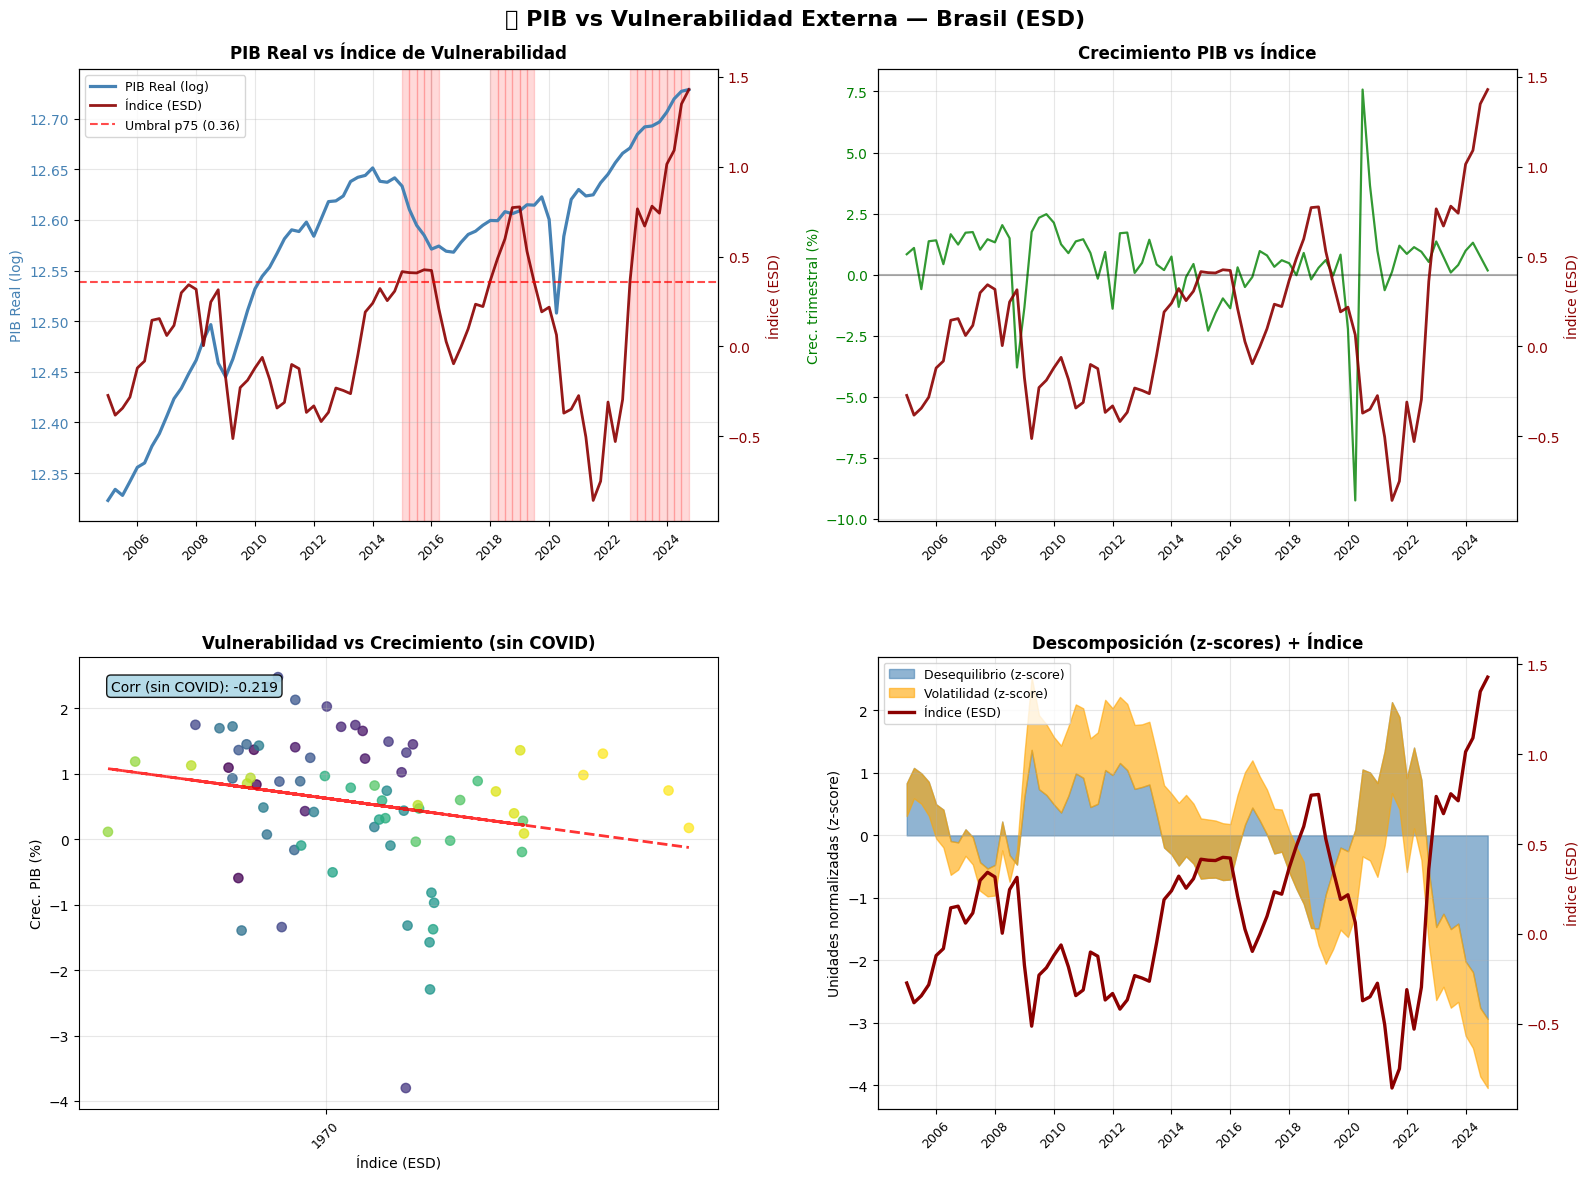

✅ Figura guardada: covid_correlation_analysis.pdf


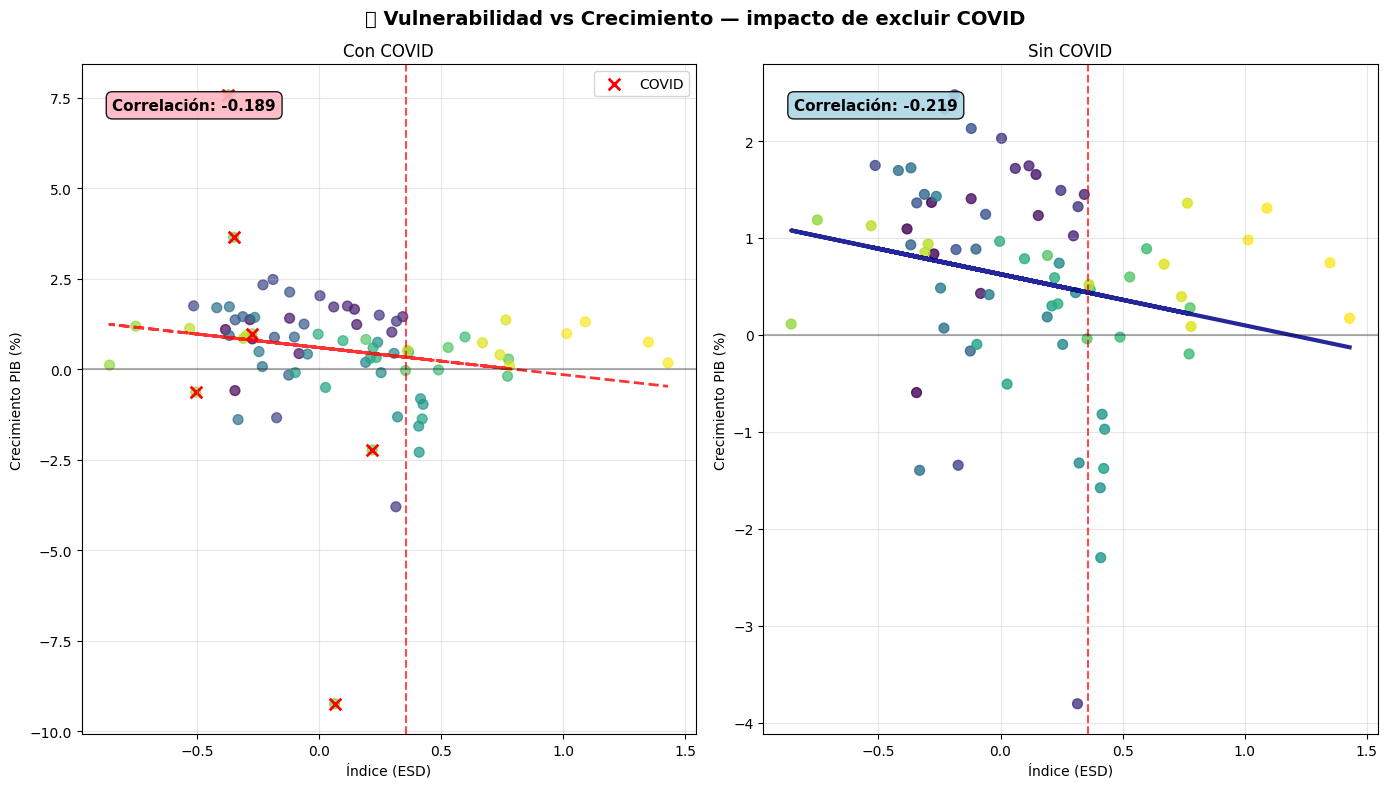

✅ Diagnóstico visual generado correctamente.


In [16]:
# ==============================================================================
# FASE 6 → DIAGNÓSTICO VISUAL (autocontenido para ESD)
#   Requiere que ya existan (de tu FASE 6 ESD):
#     - vuln_df  : DataFrame con columna 'indicator' (índice ESD)
#     - components: DataFrame con columnas ['Desequilibrio','Volatilidad'] (z-scores)
#     - df_aligned, figures_dir, final_model_results
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import YearLocator, DateFormatter

# ------------------ 1) Puente: Fase 6 -> estructura de visualización ------------------

def create_visualization_structure_from_phase6(vuln_df, components, threshold_percentile=75):
    """
    Adapta (vuln_df, components) a la estructura que consumen las funciones de plotting.
    No usa pesos; es 100% compatible con el enfoque ESD.
    """
    out = pd.DataFrame(index=vuln_df.index)

    # Índice de vulnerabilidad (nombre estándar que esperan los plots)
    if "indicator" in vuln_df.columns:
        idx = vuln_df["indicator"].rename("Vulnerability_Index_Optimized")
    else:
        # fallback si hubiera cambiado el nombre
        col_guess = [c for c in vuln_df.columns if "vulner" in c.lower() or "indic" in c.lower()]
        if not col_guess:
            raise ValueError("No se encontró la columna del indicador en vuln_df.")
        idx = vuln_df[col_guess[0]].rename("Vulnerability_Index_Optimized")

    out["Vulnerability_Index_Optimized"] = idx
    out["Vulnerability_Index"] = idx  # alias de compatibilidad

    # Componentes (z-scores creados en Fase 6)
    out["Desequilibrium_Component"] = components["Desequilibrio"].reindex(out.index)
    out["Volatility_Component"]     = components["Volatilidad"].reindex(out.index)

    # Umbral por percentil histórico
    vals = out["Vulnerability_Index_Optimized"].dropna().values
    thr = np.percentile(vals, threshold_percentile) if len(vals) else np.nan
    out["High_Vulnerability_Episode"] = out["Vulnerability_Index_Optimized"] > thr
    out["Vulnerability_Percentile"]   = out["Vulnerability_Index_Optimized"].rank(pct=True) * 100

    return {
        "vulnerability_data": out,
        "vulnerability_threshold": thr,
        "model_diagnostics": {
            "ect_coefficient": final_model_results.get("ect_coefficient", np.nan),
            "r_squared": final_model_results.get("r_squared", np.nan),
        }
    }

optimized_vulnerability_results = create_visualization_structure_from_phase6(
    vuln_df=vuln_df,
    components=components,
    threshold_percentile=75
)

# ------------------ 2) Plots: overview 4 paneles (versión ESD, sin pesos) --------------

def plot_gdp_vulnerability_analysis_esd(df_aligned, vulnerability_results, figsize=(16, 12), save_fig=False):
    """
    Análisis integral para el índice ESD (sin pesos). Panel 4 apila z-scores de
    Desequilibrio y Volatilidad, y superpone el índice ESD en eje secundario.
    """
    vd = vulnerability_results["vulnerability_data"]
    threshold = vulnerability_results["vulnerability_threshold"]

    # Series base
    vuln_series = vd["Vulnerability_Index_Optimized"]
    gdp_level   = df_aligned['log_gdp_brazil'].dropna()
    gdp_growth  = (df_aligned['log_gdp_brazil'].diff() * 100).dropna()

    # Alineación
    common_idx = vuln_series.index.intersection(gdp_level.index)

    plt.style.use('default')
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    fig.suptitle('📊 PIB vs Vulnerabilidad Externa — Brasil (ESD)',
                 fontsize=16, fontweight='bold', y=0.98)

    # ---- Panel 1: PIB (log) vs Índice ----
    ax1 = axes[0,0]
    ax1.plot(common_idx, gdp_level.loc[common_idx], color='steelblue', linewidth=2.3, label='PIB Real (log)')
    ax1.set_ylabel('PIB Real (log)', color='steelblue'); ax1.tick_params(axis='y', labelcolor='steelblue')
    ax1.grid(True, alpha=0.3); ax1.set_title('PIB Real vs Índice de Vulnerabilidad', fontweight='bold', pad=8)

    ax1b = ax1.twinx()
    ax1b.plot(vd.index, vuln_series, color='darkred', linewidth=2, alpha=0.9, label='Índice (ESD)')
    if np.isfinite(threshold):
        ax1b.axhline(y=threshold, color='red', linestyle='--', alpha=0.7, label=f'Umbral p75 ({threshold:.2f})')
    ax1b.set_ylabel('Índice (ESD)', color='darkred'); ax1b.tick_params(axis='y', labelcolor='darkred')

    # Sombrear episodios altos
    if 'High_Vulnerability_Episode' in vd.columns:
        high = vd['High_Vulnerability_Episode']
        for i in range(len(high)-1):
            if bool(high.iloc[i]):
                ax1.axvspan(vd.index[i], vd.index[i+1], color='red', alpha=0.15)

    # Leyenda combinada
    l1, lab1 = ax1.get_legend_handles_labels()
    l2, lab2 = ax1b.get_legend_handles_labels()
    ax1.legend(l1+l2, lab1+lab2, loc='upper left', fontsize=9)

    # ---- Panel 2: Crecimiento vs Índice ----
    ax2 = axes[0,1]
    growth_al = gdp_growth.reindex(vd.index)
    ax2.plot(vd.index, growth_al, color='green', linewidth=1.6, alpha=0.8, label='Crecimiento PIB (%)')
    ax2.axhline(0, color='black', alpha=0.3); ax2.grid(True, alpha=0.3)
    ax2.set_title('Crecimiento PIB vs Índice', fontweight='bold', pad=8)
    ax2.set_ylabel('Crec. trimestral (%)', color='green'); ax2.tick_params(axis='y', labelcolor='green')

    ax2b = ax2.twinx()
    ax2b.plot(vd.index, vuln_series, color='darkred', linewidth=2, alpha=0.9, label='Índice (ESD)')
    ax2b.set_ylabel('Índice (ESD)', color='darkred'); ax2b.tick_params(axis='y', labelcolor='darkred')

    # ---- Panel 3: Scatter sin COVID ----
    ax3 = axes[1,0]
    df_sc = pd.DataFrame({'v': vuln_series, 'g': growth_al}).dropna()
    covid_mask = (df_sc.index.year == 2020) | ((df_sc.index.year == 2021) & (df_sc.index.quarter <= 2))
    clean = df_sc.loc[~covid_mask]
    ax3.scatter(clean['v'], clean['g'], c=clean.index.year, cmap='viridis', alpha=0.75, s=45)
    if len(clean) > 5:
        z = np.polyfit(clean['v'], clean['g'], 1); p = np.poly1d(z)
        ax3.plot(clean['v'], p(clean['v']), 'r--', lw=2, alpha=0.8, label='Tendencia (sin COVID)')
        ax3.text(0.05, 0.95, f"Corr (sin COVID): {clean['v'].corr(clean['g']):.3f}",
                 transform=ax3.transAxes, ha='left', va='top',
                 bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.9))
    ax3.grid(True, alpha=0.3); ax3.set_xlabel('Índice (ESD)'); ax3.set_ylabel('Crec. PIB (%)')
    ax3.set_title('Vulnerabilidad vs Crecimiento (sin COVID)', fontweight='bold')

    # ---- Panel 4: Descomposición (z-scores) + Índice en eje secundario ----
    ax4 = axes[1,1]
    dates = vd.index
    deseq = vd['Desequilibrium_Component']
    volat = vd['Volatility_Component']

    base = np.zeros(len(dates))
    ax4.fill_between(dates, base, base + deseq, alpha=0.6, color='steelblue', label='Desequilibrio (z-score)')
    ax4.fill_between(dates, base + deseq, base + deseq + volat, alpha=0.6, color='orange', label='Volatilidad (z-score)')
    ax4.set_ylabel('Unidades normalizadas (z-score)')
    ax4.grid(True, alpha=0.3); ax4.set_title('Descomposición (z-scores) + Índice', fontweight='bold')

    ax4b = ax4.twinx()
    ax4b.plot(dates, vuln_series, color='darkred', lw=2.4, label='Índice (ESD)')
    ax4b.set_ylabel('Índice (ESD)', color='darkred'); ax4b.tick_params(axis='y', labelcolor='darkred')

    # Leyenda del panel 4 (combinar ambas)
    l1, lab1 = ax4.get_legend_handles_labels()
    l2, lab2 = ax4b.get_legend_handles_labels()
    ax4.legend(l1 + l2, lab1 + lab2, loc='upper left', fontsize=9)

    # Formato fechas
    for ax in axes.flat:
        ax.tick_params(axis='x', rotation=45, labelsize=9)
        if hasattr(ax, 'xaxis'):
            ax.xaxis.set_major_locator(YearLocator(2))
            ax.xaxis.set_major_formatter(DateFormatter('%Y'))

    plt.tight_layout(); plt.subplots_adjust(top=0.93, hspace=0.3, wspace=0.25)

    if save_fig:
        plt.savefig(f"{figures_dir}/vulnerability_analysis.pdf", format='pdf', dpi=300, bbox_inches='tight')
        print("✅ Figura guardada: vulnerability_analysis.pdf")

    plt.show()

# ------------------ 3) Plot de correlación COVID vs sin COVID --------------------------

def plot_vulnerability_correlation_analysis(df_aligned, vulnerability_results, figsize=(14, 8)):
    """
    Comparativa de correlación Índice–Crecimiento con y sin COVID. Guarda PDF.
    """
    vd = vulnerability_results['vulnerability_data']
    threshold = vulnerability_results['vulnerability_threshold']
    vuln_col = 'Vulnerability_Index_Optimized' if 'Vulnerability_Index_Optimized' in vd.columns else 'Vulnerability_Index'

    gdp_growth = (df_aligned['log_gdp_brazil'].diff() * 100).dropna()
    analysis = pd.DataFrame({
        'vulnerability': vd[vuln_col],
        'gdp_growth': gdp_growth.reindex(vd.index),
        'year': vd.index.year,
        'quarter': vd.index.quarter
    }).dropna()

    covid_mask = (analysis['year'] == 2020) | ((analysis['year'] == 2021) & (analysis['quarter'] <= 2))
    clean = analysis.loc[~covid_mask]
    covid = analysis.loc[covid_mask]

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle('🔍 Vulnerabilidad vs Crecimiento — impacto de excluir COVID', fontsize=14, fontweight='bold')

    # Left: con COVID
    ax1 = axes[0]
    ax1.scatter(analysis['vulnerability'], analysis['gdp_growth'], c=analysis['year'], cmap='viridis', alpha=0.7, s=50)
    if len(analysis) > 5:
        z1 = np.polyfit(analysis['vulnerability'], analysis['gdp_growth'], 1); p1 = np.poly1d(z1)
        ax1.plot(analysis['vulnerability'], p1(analysis['vulnerability']), "r--", alpha=0.8, lw=2)
        corr1 = analysis['vulnerability'].corr(analysis['gdp_growth'])
        ax1.text(0.05, 0.95, f'Correlación: {corr1:.3f}', transform=ax1.transAxes,
                 fontsize=11, weight='bold', va='top', bbox=dict(boxstyle="round,pad=0.4", facecolor="lightpink", alpha=0.9))
    if np.isfinite(threshold):
        ax1.axvline(threshold, color='red', ls='--', alpha=0.7)
    ax1.axhline(0, color='black', alpha=0.3)
    if len(covid) > 0:
        ax1.scatter(covid['vulnerability'], covid['gdp_growth'], color='red', marker='x', s=70, lw=2, label='COVID')
        ax1.legend()
    ax1.set_xlabel('Índice (ESD)'); ax1.set_ylabel('Crecimiento PIB (%)'); ax1.grid(True, alpha=0.3)
    ax1.set_title('Con COVID')

    # Right: sin COVID
    ax2 = axes[1]
    if len(clean) > 0:
        ax2.scatter(clean['vulnerability'], clean['gdp_growth'], c=clean['year'], cmap='viridis', alpha=0.8, s=50)
        if len(clean) > 5:
            z2 = np.polyfit(clean['vulnerability'], clean['gdp_growth'], 1); p2 = np.poly1d(z2)
            ax2.plot(clean['vulnerability'], p2(clean['vulnerability']), "darkblue", lw=3, alpha=0.85)
            corr2 = clean['vulnerability'].corr(clean['gdp_growth'])
            ax2.text(0.05, 0.95, f'Correlación: {corr2:.3f}', transform=ax2.transAxes,
                     fontsize=11, weight='bold', va='top',
                     bbox=dict(boxstyle="round,pad=0.4", facecolor="lightblue", alpha=0.9))
    if np.isfinite(threshold):
        ax2.axvline(threshold, color='red', ls='--', alpha=0.7)
    ax2.axhline(0, color='black', alpha=0.3)
    ax2.set_xlabel('Índice (ESD)'); ax2.set_ylabel('Crecimiento PIB (%)'); ax2.grid(True, alpha=0.3)
    ax2.set_title('Sin COVID')

    plt.tight_layout()
    plt.savefig(f"{figures_dir}/covid_correlation_analysis.pdf", format='pdf', dpi=300, bbox_inches='tight')
    print("✅ Figura guardada: covid_correlation_analysis.pdf")
    plt.show()

# ------------------ 4) Ejecutar y guardar figuras --------------------------------------

plot_gdp_vulnerability_analysis_esd(
    df_aligned,
    optimized_vulnerability_results,
    save_fig=True
)

covid_analysis = plot_vulnerability_correlation_analysis(
    df_aligned,
    optimized_vulnerability_results
)

print("✅ Diagnóstico visual generado correctamente.")


=== Atribución de μ_t por variables (media / p95 / último) ===
                  mean     p95    last
const           0.8676  0.8676  0.8676
us_10y          0.0071  0.0110  0.0085
log_tot_brazil -1.2728 -1.2706 -1.2723

=== Atribución de σ_t^2 por shocks (share medio / último) ===
                  mean_share  last_share
d_spread                69.3        21.2
d_us10y                 30.9        79.3
d_log_tot_brazil        -0.2        -0.5


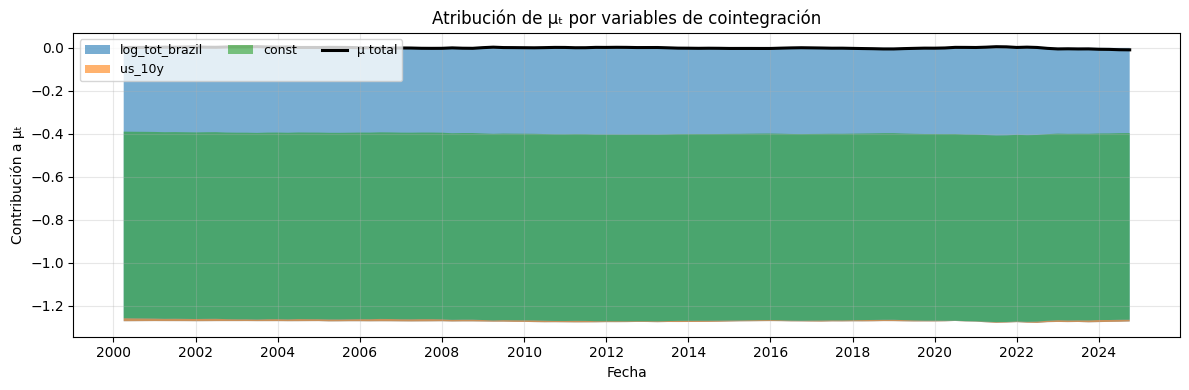

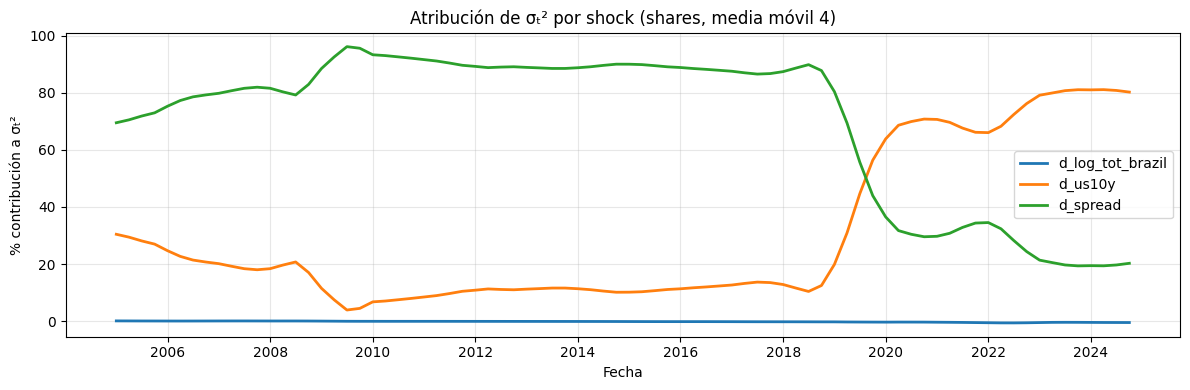

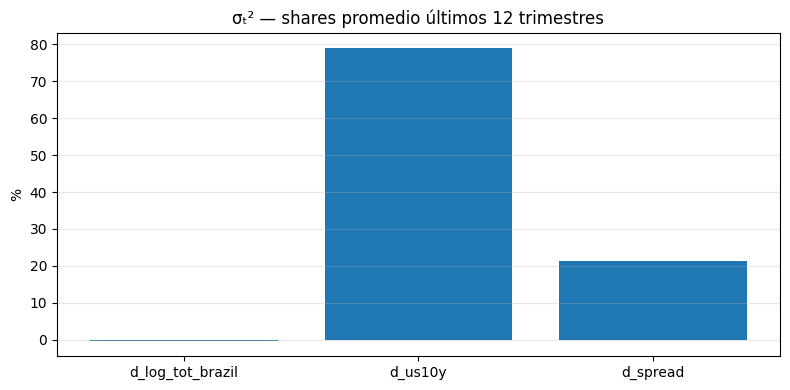

In [17]:
# ==============================================================================
# FASE 6 · ATRIBUCIÓN DEL ÍNDICE (μ/σ) A VARIABLES Y SHOCKS
# Requiere: df_aligned, final_model_results, vuln_df, components, g, shock_cols, win
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import YearLocator, DateFormatter

# ---------- A) Atribución de μ_t por variables (cointegración) y lags del ECT ----------

def mu_decomposition_by_variable(df, final_model_results, level_vars=None, ect_name='ECT'):
    """
    Devuelve:
      - mu_total: Serie igual a μ_t (suma α_L * ECT_{t-L})
      - mu_by_var: DataFrame con contribuciones por variable de cointegración (+ 'const')
      - mu_by_lag: DataFrame con contribuciones por lag del ECT (L=1,2,...)
    """
    # ECT y parámetros
    ect = final_model_results['ect'].reindex(df.index)
    params = final_model_results['model'].params
    beta = final_model_results['cointegration_model'].params

    # Detectar lags del ECT en el modelo (α_L)
    alphas = {}
    for name, val in params.items():
        lname = name.lower()
        if ect_name.lower() in lname:
            # captura formatos ECT_L1, ECTL2, 'ECT lag3', etc.
            import re
            m = re.search(r'(?:_?L|lag)\s*(\d+)', lname)
            L = int(m.group(1)) if m else 1
            alphas[L] = float(val)

    if not alphas:
        raise ValueError("No se encontraron coeficientes α_L del ECT en el modelo.")

    # Variables de cointegración (si no se pasan, inferimos quitando 'const' si existe)
    if level_vars is None:
        level_vars = [k for k in beta.index if k.lower() not in ('const','intercept')]

    # μ total como en tu helper
    mu_total = pd.Series(0.0, index=df.index, name='mu_total')
    for L, aL in alphas.items():
        mu_total += aL * ect.shift(L)

    # Descomposición por variable (lineal: μ_t = Σ_L α_L * (β0 + Σ_m β_m z_{m,t-L}))
    mu_by_var = pd.DataFrame(0.0, index=df.index, columns=level_vars + ['const'])
    for L, aL in alphas.items():
        # Constante (si existe)
        b0 = float(beta.get('const', beta.get('Intercept', 0.0)))
        if b0 != 0.0:
            mu_by_var['const'] += aL * b0

        # Variables de cointegración
        for v in level_vars:
            bv = float(beta[v])
            mu_by_var[v] += aL * bv * df[v].shift(L)

    # Descomposición por lag del ECT
    mu_by_lag = pd.DataFrame(0.0, index=df.index, columns=[f'ECT_L{L}' for L in sorted(alphas)])
    for L, aL in alphas.items():
        mu_by_lag[f'ECT_L{L}'] = aL * ect.shift(L)

    return mu_total, mu_by_var, mu_by_lag

mu_total, mu_by_var, mu_by_lag = mu_decomposition_by_variable(
    df_aligned, final_model_results, level_vars=None, ect_name='ECT'
)

# Chequeo: μ_total debe alinear con la μ usada en tu índice
# (si tu μ la llamaste 'mu' en memoria, puedes verificar)
# print(mu_total.corr(mu), mu_total.sub(mu).abs().max())

# ---------- B) Atribución de σ_t^2 por shocks (Shapley-like del cuadrático) ------------

def sigma_and_var_contribs(df, shock_cols, g, window=40, min_periods=None):
    """
    Devuelve:
      - sigma: Serie de σ_t (>=0)
      - var_contribs: DataFrame con contribuciones c_i,t = g_i * (Σ_t g)_i  (suma = σ_t^2)
      - var_shares: DataFrame con shares c_i,t / σ_t^2
    """
    if min_periods is None:
        min_periods = max(20, len(shock_cols)*3)

    idx = df.index
    sigma = pd.Series(np.nan, index=idx, name='sigma_shock')
    var_contribs = pd.DataFrame(np.nan, index=idx, columns=shock_cols)

    for t in range(len(df)):
        start = max(0, t-window+1)
        sample = df.iloc[start:t+1][shock_cols].dropna()
        if len(sample) >= min_periods:
            S = sample.cov().values
            gvec = np.asarray(g, dtype=float).reshape(-1)
            sigma2 = float(gvec @ S @ gvec)
            sigma.iloc[t] = np.sqrt(max(0.0, sigma2))
            c_vec = gvec * (S @ gvec)  # contribuciones a σ^2
            var_contribs.iloc[t] = c_vec

    var_shares = var_contribs.div((sigma**2), axis=0)
    return sigma, var_contribs, var_shares

sigma_chk, var_contribs, var_shares = sigma_and_var_contribs(
    df=df_aligned, shock_cols=shock_cols, g=g, window=win
)

# ---------- C) Atribución del ÍNDICE (-μ/σ): diagnósticos prácticos --------------------

# 1) μ por variables: niveles (media, p95) y último dato
mu_var_stats = pd.DataFrame({
    'mean': mu_by_var.mean(),
    'p95':  mu_by_var.quantile(0.95),
    'last': mu_by_var.iloc[-1]
}).sort_values('mean', ascending=False)

# 2) σ^2 por shocks: medias de shares y último dato
var_shares_stats = pd.DataFrame({
    'mean_share': var_shares.mean(),
    'last_share': var_shares.iloc[-1]
}).sort_values('mean_share', ascending=False)

print("=== Atribución de μ_t por variables (media / p95 / último) ===")
print(mu_var_stats.round(4).to_string())

print("\n=== Atribución de σ_t^2 por shocks (share medio / último) ===")
print((100*var_shares_stats).round(1).to_string())

# ---------- D) Gráficos rápidos de atribución -----------------------------------------

# (1) Stacked area de μ_t por variable + línea μ_total
common = mu_by_var.index.intersection(mu_total.index)
plt.figure(figsize=(12,4))
base = np.zeros(len(common))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i, col in enumerate(mu_by_var.columns):
    vals = mu_by_var.loc[common, col].values
    plt.fill_between(common, base, base + vals, alpha=0.6, label=col)
    base = base + vals
plt.plot(common, mu_total.loc[common], lw=2.2, label='μ total', color='black')
plt.title('Atribución de μₜ por variables de cointegración')
plt.xlabel('Fecha'); plt.ylabel('Contribución a μₜ')
plt.legend(loc='upper left', ncol=3, fontsize=9); plt.grid(alpha=0.3)
ax = plt.gca(); ax.xaxis.set_major_locator(YearLocator(2)); ax.xaxis.set_major_formatter(DateFormatter('%Y'))
plt.tight_layout(); plt.savefig(f'{figures_dir}/mu_attribution_by_variable.pdf', dpi=300, bbox_inches='tight'); plt.show()

# (2) Shares de σ_t^2 por shock (suavizados) y barras de promedio reciente
shares_plot = var_shares.rolling(4, min_periods=1).mean() * 100.0  # suaviza en 1 año si trimestral
plt.figure(figsize=(12,4))
for sc in shock_cols:
    plt.plot(shares_plot.index, shares_plot[sc], lw=2, label=sc)
plt.title('Atribución de σₜ² por shock (shares, media móvil 4)')
plt.xlabel('Fecha'); plt.ylabel('% contribución a σₜ²')
plt.legend(); plt.grid(alpha=0.3)
ax = plt.gca(); ax.xaxis.set_major_locator(YearLocator(2)); ax.xaxis.set_major_formatter(DateFormatter('%Y'))
plt.tight_layout(); plt.savefig(f'{figures_dir}/sigma2_shares_by_shock.pdf', dpi=300, bbox_inches='tight'); plt.show()

# (3) Barras con shares medios de los últimos 3 años (u otro período)
last_n = 12  # ~3 años si trimestral
tail = var_shares.tail(last_n).mean() * 100.0
plt.figure(figsize=(8,4))
plt.bar(tail.index, tail.values)
plt.title(f'σₜ² — shares promedio últimos {last_n} trimestres')
plt.ylabel('%'); plt.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig(f'{figures_dir}/sigma2_shares_lastN_bars.pdf', dpi=300, bbox_inches='tight'); plt.show()


In [18]:
# % de cada variable sobre |μ_t| (última observación)
mu_last = mu_by_var.iloc[-1]
mu_last_abs_sum = mu_by_var.iloc[-1].abs().sum()
print("\n% de |μ_t| por variable (última obs.):")
print(((mu_last.abs() / mu_last_abs_sum) * 100).round(1).sort_values(ascending=False).to_string())

# % de σ_t^2 por shock (últimos 12 trimestres promedio)
tail_shares = (var_shares.tail(12).mean() * 100).round(1).sort_values(ascending=False)
print("\n% de σ_t^2 por shock (promedio últimos 12 trimestres):")
print(tail_shares.to_string())



% de |μ_t| por variable (última obs.):
log_tot_brazil    59.2
const             40.4
us_10y             0.4

% de σ_t^2 por shock (promedio últimos 12 trimestres):
d_us10y             79.2
d_spread            21.3
d_log_tot_brazil    -0.5


✅ Figura guardada: vulnerability_analysis.pdf


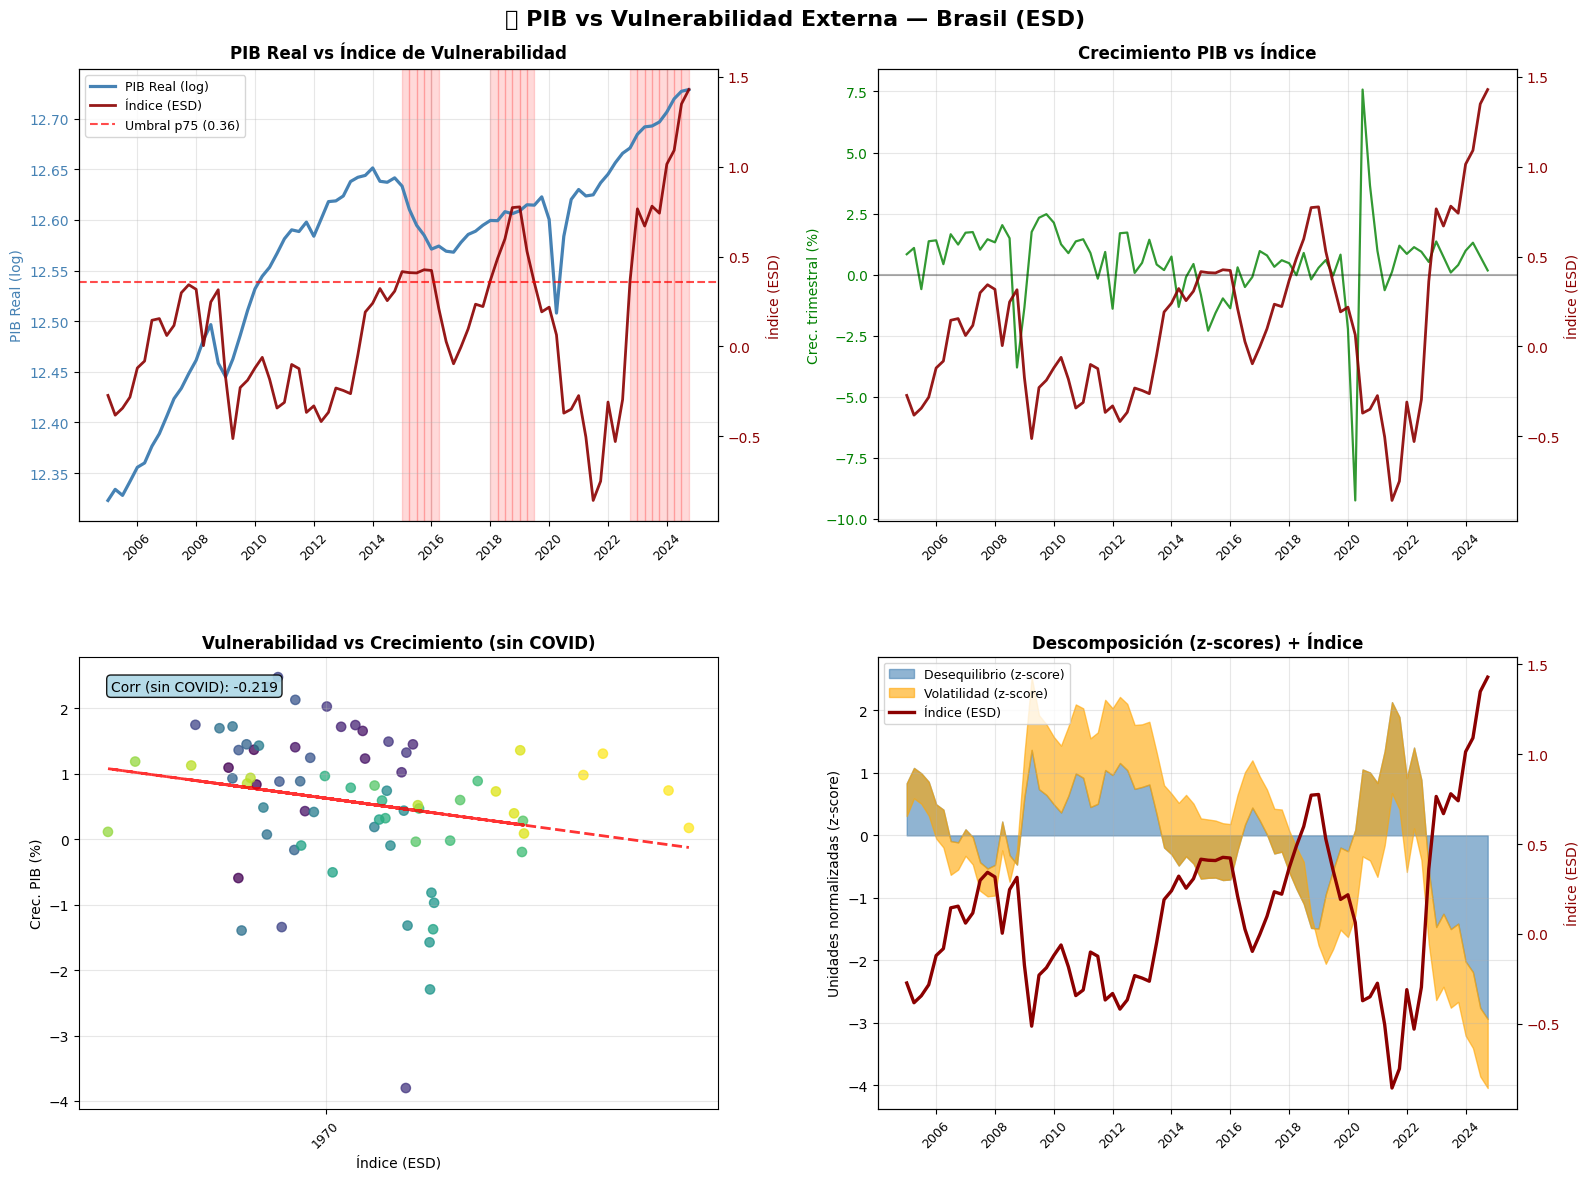

✅ Figura guardada: covid_correlation_analysis.pdf


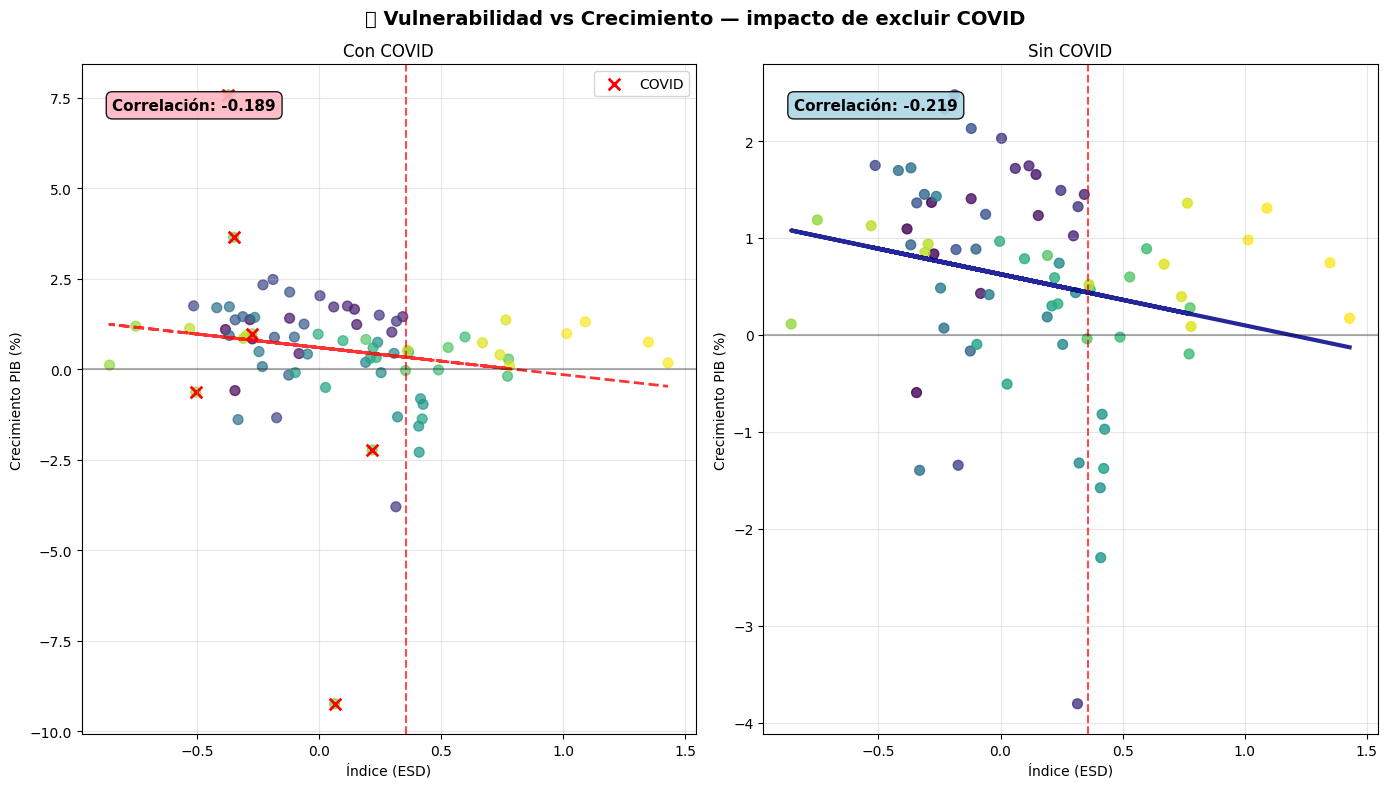

✅ FASE 7 completada. Archivos generados:
  · figures/vulnerability_analysis.pdf → OK
  · figures/covid_correlation_analysis.pdf → OK
  · figures/vulnerability_esd_overview.pdf → OK
  · figures/vulnerability_esd_decomposition.pdf → OK
  · figures/vulnerability_brazil_ESD.csv → OK
  · figures/vulnerability_dataset_final.csv → OK


In [19]:
# ==============================================================================
# FASE 7 · VISUALIZACIONES Y SALIDAS FINALES
# Requiere: df_aligned, vuln_df, components, figures_dir
# Opcional: plot_gdp_vulnerability_analysis_esd(), plot_vulnerability_correlation_analysis()
# ==============================================================================

import os, pandas as pd

# 1) Preparar estructura para plots finales (si no la tienes ya)
def create_visualization_structure_from_phase6(vuln_df, components, threshold_percentile=75):
    out = pd.DataFrame(index=vuln_df.index)
    idx = vuln_df['indicator'].rename('Vulnerability_Index_Optimized')
    out['Vulnerability_Index_Optimized'] = idx
    out['Vulnerability_Index'] = idx
    out['Desequilibrium_Component'] = components['Desequilibrio'].reindex(out.index)
    out['Volatility_Component']     = components['Volatilidad'].reindex(out.index)
    vals = out['Vulnerability_Index_Optimized'].dropna().values
    thr = np.percentile(vals, threshold_percentile) if len(vals) else np.nan
    out['High_Vulnerability_Episode'] = out['Vulnerability_Index_Optimized'] > thr
    out['Vulnerability_Percentile']   = out['Vulnerability_Index_Optimized'].rank(pct=True) * 100
    return {'vulnerability_data': out, 'vulnerability_threshold': thr}

viz = create_visualization_structure_from_phase6(vuln_df, components, threshold_percentile=75)

# 2) Ejecutar figuras “publicables”
#    Si ya definiste estas funciones en la celda anterior, simplemente llama:
try:
    plot_gdp_vulnerability_analysis_esd(df_aligned, viz, save_fig=True)
except NameError:
    print("Nota: define plot_gdp_vulnerability_analysis_esd() o importa tu versión antes de Fase 7.")

try:
    plot_vulnerability_correlation_analysis(df_aligned, viz)
except NameError:
    print("Nota: define plot_vulnerability_correlation_analysis() o importa tu versión antes de Fase 7.")

# 3) (Opcional) Exportar dataset final “listo para plotear”
final_export = viz['vulnerability_data'].copy()
final_export.to_csv(f"{figures_dir}/vulnerability_dataset_final.csv", encoding="utf-8")

# 4) Resumen de salidas
generated = [
    f"{figures_dir}/vulnerability_analysis.pdf",
    f"{figures_dir}/covid_correlation_analysis.pdf",
    f"{figures_dir}/vulnerability_esd_overview.pdf",
    f"{figures_dir}/vulnerability_esd_decomposition.pdf",
    f"{figures_dir}/vulnerability_brazil_ESD.csv",
    f"{figures_dir}/vulnerability_dataset_final.csv",
]
print("✅ FASE 7 completada. Archivos generados:")
for p in generated:
    print("  ·", p, "→", "OK" if os.path.exists(p) else "pendiente")


✅ Figura guardada: figures/vulnerability_esd_decomposition_annotated.pdf


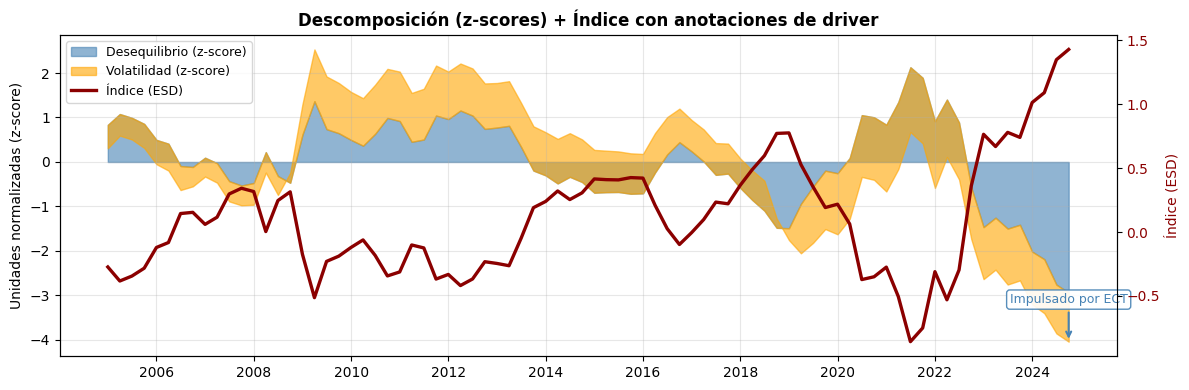

In [20]:
# ==============================================================================
# DECOMPOSICIÓN (z-scores) + ANOTACIONES AUTOMÁTICAS DE DRIVER
# Requiere: components[['Desequilibrio','Volatilidad']], vuln_df['indicator'], figures_dir
# ==============================================================================

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.dates import YearLocator, DateFormatter

def plot_decomposition_annotated(components, indicator, top_k=5, min_percentile=0.75,
                                 driver_gap=0.5, save=True, fname='vulnerability_esd_decomposition_annotated.pdf'):
    """
    top_k: nº de picos del índice a anotar (por valor).
    min_percentile: umbral mínimo del índice para considerar pico (e.g. p75).
    driver_gap: margen mínimo (en z-scores) para declarar "ECT" o "Riesgo". Si no se supera → "Mixto".
    """

    # --- Preparar series
    ind = indicator.dropna().copy()
    comp = components.reindex(ind.index).dropna().copy()
    deseq_z = comp['Desequilibrio']         # z-score de μ (negativo = más contractivo)
    vol_z   = comp['Volatilidad']           # z-score de σ (positivo = más riesgo)

    # --- Plot base (igual que el de Fase 6, panel 4)
    dates = comp.index
    base = np.zeros(len(dates))

    fig, ax = plt.subplots(1, 1, figsize=(12, 4))
    ax.fill_between(dates, base, base + deseq_z, alpha=0.6, color='steelblue', label='Desequilibrio (z-score)')
    ax.fill_between(dates, base + deseq_z, base + deseq_z + vol_z, alpha=0.6, color='orange', label='Volatilidad (z-score)')
    ax.set_ylabel('Unidades normalizadas (z-score)')
    ax.grid(True, alpha=0.3)
    ax.set_title('Descomposición (z-scores) + Índice con anotaciones de driver', fontweight='bold')

    axr = ax.twinx()
    axr.plot(dates, ind.reindex(dates), color='darkred', lw=2.4, label='Índice (ESD)')
    axr.set_ylabel('Índice (ESD)', color='darkred'); axr.tick_params(axis='y', labelcolor='darkred')

    # Leyenda combinada
    l1, lab1 = ax.get_legend_handles_labels(); l2, lab2 = axr.get_legend_handles_labels()
    ax.legend(l1 + l2, lab1 + lab2, loc='upper left', fontsize=9)

    # --- Detectar picos a anotar
    thr = ind.quantile(min_percentile)
    cand = ind[ind >= thr].sort_values(ascending=False).head(top_k)
    # Evitar marcas muy juntas: si dos fechas están muy próximas, nos quedamos con la más alta
    selected = []
    min_sep = max(1, int(len(ind) * 0.02))  # ~2% del tamaño de la muestra
    for t in cand.index:
        if not selected or (t - selected[-1]).days > 90:  # separación aproximada trimestral
            selected.append(t)

    # --- Reglas de driver:
    #     score_ect  = -deseq_z (porque negativo = más contractivo)
    #     score_risk = max(vol_z, 0) (solo riesgo por encima de la media)
    #     Si |score_ect - score_risk| >= driver_gap  → ganador claro; si no → mixto
    for t in selected:
        if t not in comp.index: 
            continue
        se = float((-deseq_z.loc[t]))     # ECT "contractivo" en unidades +z
        sr = float(max(vol_z.loc[t], 0))  # Riesgo solo cuando está por encima de su media
        label = 'Mixto'
        color = 'gray'
        if (se - sr) >= driver_gap:
            label, color = 'Impulsado por ECT', 'steelblue'
        elif (sr - se) >= driver_gap:
            label, color = 'Impulsado por riesgo', 'orange'

        # Anotación en el gráfico
        y = float((deseq_z.loc[t] + vol_z.loc[t]))  # borde superior del área apilada
        ax.annotate(label,
                    xy=(t, y),
                    xytext=(t, y + 0.8),
                    textcoords='data',
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.5),
                    ha='center', va='bottom',
                    fontsize=9, color=color,
                    bbox=dict(boxstyle='round,pad=0.25', fc='white', ec=color, alpha=0.9))

    # Formato fechas
    ax.xaxis.set_major_locator(YearLocator(2))
    ax.xaxis.set_major_formatter(DateFormatter('%Y'))
    plt.tight_layout()

    if save:
        plt.savefig(f"{figures_dir}/{fname}", dpi=300, bbox_inches='tight')
        print("✅ Figura guardada:", f"{figures_dir}/{fname}")

    plt.show()

# ---- Llamada (usa tus objetos actuales) ----
plot_decomposition_annotated(
    components=components,
    indicator=vuln_df['indicator'],
    top_k=5,                # nº de picos a anotar
    min_percentile=0.75,    # picos por encima del p75
    driver_gap=0.5,         # diferencia mínima en z-scores para declarar ganador
    save=True,
    fname='vulnerability_esd_decomposition_annotated.pdf'
)
